# Progetto Eurovision 2026
## Predizione dei risultati con Modelli Lineari, Regolarizzazione e Gravity Features


---

## Abstract

Il presente lavoro propone una **pipeline end-to-end di Machine Learning** per la previsione dei risultati dell'Eurovision Song Contest 2026 limitata a metodi **lineari** e **probabilistici**.

L'analisi integra quattro fonti di dati eterogenee — risultati storici Eurovision (2016–2025), feature audio Spotify, voti bilaterali tra nazioni, dati gravitazionali CEPII — e affronta tre task complementari:

1. **Task A — Regressione** del punteggio totale (`Points_Final`) con OLS, Ridge e Lasso.
2. **Task B — Classificazione binaria** della qualificazione in finale (`Grand_Final_Ind`) con Logistic Regression, LDA, QDA e Naive Bayes, contrapponendo modelli generativi e discriminativi.
3. **Task C — Classificazione multi-classe** della fascia di piazzamento (Top 3 / Top 10 / Top 20 / Bottom) tramite Regressione Logistica Multinomiale.

Tutti i modelli sono ottimizzati via **k-fold cross-validation temporale** (`TimeSeriesSplit`) sui dati 2016–2024, validati sul **hold-out 2025** e infine applicati al **test set 2026**. Particolare attenzione è dedicata alla **prevenzione del data leakage** nel feature engineering storico e alla costruzione di **Gravity Features** ispirate al Gravity Model of Trade per quantificare l'affinità geo-culturale tra paesi.

I risultati confermano che (i) la regolarizzazione **Ridge** offre la stima più robusta del punteggio finale (MAE ≈ 78 punti, R² ≈ 0.28); (ii) le metriche di engagement della community (**OGAE Points**, **MyESB Community**) sono i predittori più forti, sopravvivendo persino alla feature selection di Lasso; (iii) per la qualificazione binaria, **LDA** e **Logistic Regression** dominano in modo complementare (LDA su Accuracy, Logistic su ROC-AUC). Il confine di separazione delle classi risulta fondamentalmente lineare, validando l'impianto metodologico del corso.

## 1. Introduzione

### 1.1 Contesto e motivazione

L'Eurovision Song Contest è uno dei più grandi eventi televisivi al mondo (oltre 160 milioni di spettatori) e rappresenta un caso di studio particolarmente interessante per il Machine Learning: il risultato finale è il prodotto di un **mix complesso di fattori musicali, geopolitici, demografici e di engagement comunitario** che si presta a un'analisi quantitativa rigorosa.

A differenza di altri contest musicali, l'Eurovision combina giuria professionale e televoto, ed è da sempre attraversato da dinamiche di **voto di blocco** (paesi nordici, ex-jugoslavi, ex-URSS, mediterranei) che la letteratura economica modellizza efficacemente con strumenti tipici del **Gravity Model of Trade** (distanza geografica, lingua comune, legami coloniali).

### 1.2 Obiettivi del progetto

Il progetto persegue tre obiettivi specifici:

1. Costruire una **pipeline di ML interpretabile** attraverso metodi di machine learning come: regressione lineare, regolarizzazione L1/L2, modelli probabilistici discriminativi e generativi.
2. **Predire i risultati dell'Eurovision 2026** producendo tre output complementari per ciascuna delle 35 nazioni partecipanti: punteggio finale stimato, probabilità di qualificazione in finale, fascia di piazzamento.
3. Esplorare empiricamente **come la regolarizzazione gestisce la multicollinearità** tipica del dominio audio (es. correlazione `energy`–`loudness`) e quale combinazione di feature (storia, audio, gravità, fan-hype) massimizza la capacità predittiva fuori campione.

### 1.3 Metodologia

- **Validazione temporale**: split cronologico rigoroso (train 2016–2024, hold-out 2025, predizione 2026) per simulare la generalizzazione "in produzione" e impiego di `TimeSeriesSplit` nella k-fold CV.
- **Feature engineering anti-leakage**: tutte le feature storiche di un paese all'anno *t* sono calcolate **esclusivamente** sui dati fino all'anno *t-1* tramite `shift(1)` e medie mobili.
- **Gravity Features dinamiche**: per ogni edizione viene ricostruita la rosa effettiva dei votanti e si calcolano contiguità, lingua comune, legami coloniali e indice di prossimità ponderato sui partecipanti reali di quell'anno.
- **Confronto sistematico tra famiglie di modelli**: per il Task A (OLS vs Ridge vs Lasso), per il Task B (Logistic Regression vs LDA vs QDA vs Naive Bayes), valutati su metriche multiple (MAE, MedAE, RMSE, R² per la regressione; Accuracy, F1, ROC-AUC, Log-loss per la classificazione).

### 1.4 I dataset utilizzati e le motivazioni della scelta

Il progetto integra **quattro dataset complementari**:

| Dataset | Righe | Cosa contiene | Perché lo usiamo |
|---------|-------|---------------|------------------|
| `eurovision_master_2016_2026.xlsx` | 434 | Risultati Eurovision 2016–2025, partecipanti 2026 da predire, audio features Spotify, demografia, OGAE/MyESB | È il **dataset principale**: contiene sia le variabili target (`Points_Final`, `Place_Final`, `Grand_Final_Ind`) sia il blocco più ricco di predittori. La presenza simultanea di feature musicali e di engagement consente di confrontare l'effetto della "qualità intrinseca" del brano vs quello del "fan-hype". |
| `eurovision_voting_master.xlsx` | 9 076 | Voti bilaterali (sender → receiver, points) per ogni edizione | Essenziale per l'**EDA dei blocchi votanti** e per validare empiricamente l'ipotesi gravitazionale sui dati reali, prima di costruire le feature CEPII. |
| `CEPII/dist_cepii.xls` | ~50k coppie paese–paese | Distanza geografica (semplice, capitale, ponderata), contiguità, lingua comune, legami coloniali tra ogni coppia di stati | Fonte canonica della letteratura economica per quantificare l'**affinità geo-culturale**. È la base delle Gravity Features dinamiche. |
| `CEPII/geo_cepii.xls` | ~250 paesi | Profilo geografico singolo: area, landlocked, lingue ufficiali, profilo coloniale | Usato per **normalizzare** i nomi tramite codici ISO-3 e per derivare attributi del paese ricevente. |

**Razionale dell'integrazione:** ogni dataset, da solo, è insufficiente. Il `master` cattura il "cosa" (risultato), il `voting` cattura il "come" (chi vota chi), il `CEPII` cattura il "perché" (relazioni strutturali tra paesi). La combinazione consente di costruire un set di predittori che copre simultaneamente le dimensioni **musicale**, **storica**, **geopolitica** e **comunitaria** del fenomeno Eurovision.

## 2.  Setup, Importazione Dati e Data Cleaning

In questa prima fase importiamo le librerie scientifiche necessarie all'intera pipeline e carichiamo i quattro dataset descritti nell'introduzione.

### 2.1 Importazione delle librerie e caricamento dei dataset

Importiamo le librerie e carichiamo i quattro dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
import pycountry


warnings.filterwarnings('ignore')

# Impostazioni di visualizzazione
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Caricamento dei dataset
df_master = pd.read_excel('eurovision_master_2016_2026.xlsx')
df_voting = pd.read_excel('eurovision_voting_master.xlsx')
df_geo = pd.read_excel('CEPII/geo_cepii.xls')
df_dist = pd.read_excel('CEPII/dist_cepii.xls')

### 2.2 Dizionari delle Feature

Riportiamo per chiarezza i dizionari delle quattro fonti di dati. Questi dizionari rappresentano la "carta d'identità" delle variabili che useremo nei modelli e sono indispensabili per interpretare correttamente coefficienti e risultati nelle sezioni successive.

## Dizionario delle Feature del Dataset `eurovision_master_2016_2026.xlsx`

Il dataset combina i risultati storici dell'Eurovision Song Contest con le metriche audio dei brani estratte da Spotify. Di seguito la descrizione delle feature presenti, suddivise per categoria.

### 1. Informazioni Generali
* **`Year`**: Anno dell'edizione dell'Eurovision.
* **`Country`**: Paese partecipante (nome normalizzato).
* **`Artist`**: Nome dell'artista o del gruppo.
* **`Song`**: Titolo della canzone in gara.

### 2. Risultati e Performance
* **`Place_Final`**: Posizione in classifica nella Grand Final (`NaN` se non qualificato).
* **`Points_Final`**: Punti totali ottenuti nella Grand Final.
* **`Top 5` / `Top 10`**: Indicatori binari (1/0) che segnalano il piazzamento in Top 5 o Top 10.
* **`Big6_Ind`**: 1 se il Paese è qualificato di diritto alla finale (Big 5 + Host).
* **`Grand_Final_Ind`**: 1 se il brano si è qualificato alla Grand Final.
* **`Semi_Final_Num`**: Numero della semifinale in cui ha gareggiato (1 o 2).
* **`Semi_Place` / `Semi_Points`**: Posizione e punteggio ottenuti in semifinale.
* **`Running_Order_Final` / `Running_Order_Semi`**: Ordine di esibizione nella finale e nella semifinale.
* **`National_Final`**: 1 se il brano è stato scelto tramite una selezione nazionale televisiva.
* **`Qualification_Record`**: Tasso storico di qualificazione in finale del Paese.
* **`OGAE_Points`**: Voti assegnati dai fan club OGAE prima del contest.
* **`MyESB_Community`**: Punteggi derivati dall'app "My Eurovision Scoreboard".

### 3. Caratteristiche Demografiche e Geopolitiche
* **`Genre`**: Genere musicale del brano.
* **`Language1` ... `Language6`**: Lingue in cui è cantato il brano (fino a 6).
* **`Multiple_Language`**: 1 se il brano contiene testi in più di una lingua.
* **`National_Language_Used`**: `True` se il brano utilizza la lingua nazionale del Paese.
* **`Solo_Artist`**: 1 se l'artista è un solista.
* **`Sex`**: Genere dell'interprete (M, F, o Mixed).
* **`Number of Members`**: Numero di componenti (se gruppo).
* **`Returning_Artist_Ind`**: 1 se l'artista ha già partecipato in edizioni precedenti.
* **`EU` / `NATO`**: 1 se il Paese fa parte dell'Unione Europea / NATO.
* **`Country_Group`**: Macroregione geografica/culturale (es. Northern, Southern, Eastern).

### 4. Feature Audio (Spotify)
* **`Spotify_Track_ID` / `Spotify_URL` / `ISRC`**: Identificativi univoci e link del brano su Spotify.
* **`Album` / `Release_Date`**: Nome dell'album e data di pubblicazione (`YYYY-MM-DD`).
* **`Popularity`**: Indice di popolarità attuale su Spotify (0-100).
* **`Duration_ms`**: Durata del brano in millisecondi.
* **`Explicit`**: 1 se il brano contiene contenuti espliciti.
* **`acousticness`**: Misura (0-1) di quanto il brano sia acustico.
* **`danceability`**: Misura (0-1) della ballabilità del brano.
* **`energy`**: Misura (0-1) dell'intensità e dell'attività del brano.
* **`instrumentalness`**: Probabilità (0-1) che il brano non contenga parti vocali.
* **`liveness`**: Probabilità (0-1) che il brano sia stato registrato dal vivo.
* **`loudness`**: Volume medio in decibel (dB).
* **`speechiness`**: Misura (0-1) della presenza di parole parlate rispetto a quelle cantate.
* **`tempo`**: Battiti per minuto (BPM) stimati.
* **`valence`**: Misura (0-1) della positività musicale (es. allegria, euforia).
* **`key`**: Tonalità principale del brano (0=C, 1=C#, ecc.).
* **`mode`**: Scala musicale (0 = Minore, 1 = Maggiore).
* **`time_signature`**: Indicazione di tempo (es. 3, 4, 5).

## Dizionario delle Feature del Dataset `eurovision_voting_master.xlsx`

Questo dataset traccia la rete di votazioni tra i Paesi partecipanti all'Eurovision Song Contest. Ogni riga rappresenta una singola transazione di voto da un Paese a un altro.

### 1. Informazioni sull'Evento
* **`year`**: L'anno dell'edizione dell'Eurovision (es. 2016, 2024).
* **`round`**: La fase della competizione in cui è avvenuta la votazione (es. `final` per la serata conclusiva).

### 2. Il Paese Votante (Mittente)
Queste feature identificano la nazione che sta esprimendo la propria preferenza.
* **`sender_code`**: Codice identificativo breve (spesso a due lettere, es. `al` o `au`) del Paese che assegna i punti.
* **`sender_country`**: Nome esteso e normalizzato del Paese votante (es. "Albania", "Australia").

### 3. Il Paese Votato (Destinatario)
Queste feature identificano la nazione in gara che è oggetto della preferenza.
* **`receiver_code`**: Codice identificativo breve del Paese la cui canzone sta ricevendo i punti.
* **`receiver_country`**: Nome esteso e normalizzato del Paese in gara che riceve il voto.

### 4. Il Punteggio 
* **`points`**: Il valore esatto dei punti assegnati dal `sender` al `receiver` (nella classica scala Eurovision, tipicamente 1-8, 10 o 12 punti; se un Paese non ha votato per un altro, il valore sarà 0).

## Dizionario delle Feature: `dist_cepii.xls` (Distanze e Relazioni Bilaterali)

Questo file è strutturato per "coppie" (Origin-Destination) e traccia la distanza e i legami storici, geografici e culturali tra due Paesi.

### 1. Identificativi della Coppia
* **`iso_o`**: Codice ISO a 3 lettere del Paese di origine (Origin).
* **`iso_d`**: Codice ISO a 3 lettere del Paese di destinazione (Destination).

### 2. Metriche di Distanza
Le distanze sono calcolate utilizzando le coordinate delle città principali e sono espresse in chilometri.
* **`dist`**: Distanza semplice tra le città più popolate dei due Paesi.
* **`distcap`**: Distanza semplice calcolata tra le capitali.
* **`distw`**: Distanza ponderata (calcolata in base alla distribuzione geografica della popolazione tra le principali città di entrambi i Paesi).
* **`distwces`**: Distanza ponderata calcolata utilizzando l'indice CES (Constant Elasticity of Substitution), una metrica avanzata per modelli economici.

### 3. Legami Geografici e Storici
Queste variabili sono "dummy" (assumono valore `1` se la condizione è vera, `0` altrimenti).
* **`contig`**: Indica se i due Paesi sono contigui (condividono un confine terrestre).
* **`smctry`**: Indica se "origine" e "destinazione" fanno parte della stessa entità statale o territoriale.
* **`colony`**: Indica se i due Paesi hanno mai avuto un rapporto di colonizzatore/colonizzato.
* **`comcol`**: Indica se i due Paesi sono stati colonizzati da uno stesso colonizzatore comune.
* **`curcol`**: Indica se i due Paesi sono *attualmente* in un rapporto coloniale o di dipendenza territoriale.
* **`col45`**: Indica se il rapporto coloniale tra i due Paesi è esistito o è continuato dopo il 1945.

### 4. Legami Linguistici
* **`comlang_off`**: 1 se i due Paesi condividono una lingua ufficiale.
* **`comlang_ethno`**: 1 se i due Paesi condividono una lingua parlata da almeno il 9% della popolazione di entrambi.

## Dizionario delle Feature: `geo_cepii.xls` (Profili Geografici e Storici Singoli)

Questo file contiene i profili dei singoli Paesi e delle loro città principali, essenziale per calcolare le metriche del dataset precedente.

### 1. Identificativi del Paese
* **`iso2` / `iso3` / `cnum`**: Codici identificativi del Paese (ISO a 2 lettere, ISO a 3 lettere, e codice numerico ONU).
* **`country` / `pays`**: Nome del Paese in inglese e in francese.

### 2. Caratteristiche Fisiche e Territoriali
* **`area`**: Superficie totale del Paese in chilometri quadrati.
* **`dis_int`**: Distanza interna del Paese (misura l'estensione/dispersione geografica media per i trasporti interni).
* **`landlocked`**: 1 se il Paese non ha sbocchi sul mare (Paese senza sbocco marittimo).
* **`continent`**: Continente di appartenenza geografica.

### 3. Dati sulle Città Principali
Per molti Paesi, il dataset traccia più di una città principale per calcolare le distanze ponderate.
* **`city_en` / `city_fr`**: Nome della città in inglese e in francese.
* **`lat` / `lon`**: Latitudine e Longitudine della città.
* **`cap`**: 1 se la città in questione è la capitale del Paese.
* **`maincity`**: 1 se è la città principale/più popolosa.
* **`citynum`**: Il numero identificativo o il totale di città tracciate per quel determinato Paese nel dataset.

### 4. Profilo Linguistico
Suddivide le lingue del Paese in base allo status ufficiale e alla percentuale di parlanti.
* **`langoff_1` ... `langoff_3`**: Lingue ufficiali del Paese (fino a 3).
* **`lang20_1` ... `lang20_4`**: Lingue madri o ampiamente parlate da almeno il 20% della popolazione.
* **`lang9_1` ... `lang9_4`**: Lingue parlate da una percentuale minoritaria (tra il 9% e il 20% della popolazione).

### 5. Profilo Coloniale
* **`colonizer1` ... `colonizer4`**: Codici ISO delle nazioni che hanno storicamente colonizzato il Paese a lungo termine.
* **`short_colonizer1` ... `short_colonizer3`**: Codici ISO delle nazioni che lo hanno occupato o colonizzato solo per brevi periodi storici.

### 2.3 Pulizia dei dati e gestione dei missing values

Prima di qualsiasi modellazione applichiamo tre operazioni di pulizia:

1. **Drop dell'edizione 2020** (cancellata per COVID-19): un anno mancante introduce solo rumore nello storico, non informazione utile.
2. **Normalizzazione dei nomi paese in codici ISO-3** tramite `pycountry`. Questo passaggio è critico: la chiave ISO-3 è l'unica che consente un merging affidabile con i dataset CEPII. Un piccolo dizionario di eccezioni gestisce manualmente i casi che `pycountry` non risolve.
3. **Imputazione dei missing values**: le audio features mancanti (per i pochi brani non reperibili su Spotify) vengono imputate con la **mediana** (più robusta della media in presenza di outlier); per `OGAE_Points`: per gli anni precedenti al 2026, i valori mancanti sono stati sostituiti con 0, assumendo che l'assenza di un punteggio registrato equivalga a zero puntiricevuti; per i paesi partecipanti nel 2026, i valori mancanti sono stati stimati usando la mediana storica del paese (ovvero la mediana dei punteggi OGAE ottenuti da quel paese negli anni passati); per i paesi debuttanti nel 2026, privi di qualsiasi storico, si è ricorso alla mediana globale di tutti i punteggi OGAE storici.

In [ ]:
# 1. Drop dell'anno 2020
df_master = df_master[df_master['Year'] != 2020].copy()

# 2. Normalizzazione Nomi in codici ISO-3
def get_iso3(country_name):
    # Mapping manuale
    exceptions = {
        'United Kingdom': 'GBR', 'Russia': 'RUS', 'Czech Republic': 'CZE', 
        'North Macedonia': 'MKD', 'Moldova': 'MDA', 'The Netherlands': 'NLD',
        'Bosnia and Herzegovina': 'BIH', 'Bulgaria':'BGR', 'Montenegro':'MNE'
    }
    if country_name in exceptions:
        return exceptions[country_name]
    try:
        # Ricerca fuzzy per mappare automaticamente il paese al codice ISO alpha 3
        return pycountry.countries.search_fuzzy(country_name)[0].alpha_3
    except:
        return np.nan

df_master['iso3'] = df_master['Country'].apply(get_iso3)

# 3. Gestione Missing Values
# Imputazione di OGAE_Points con la mediana
if 'OGAE_Points' in df_master.columns:
    mask_pre = df_master['Year'] < 2026
    df_master.loc[mask_pre, 'OGAE_Points'] = df_master.loc[mask_pre, 'OGAE_Points'].fillna(0)
    
    # Per il 2026: imputiamo con la mediana paese-specifica (storica)
    mask_2026 = df_master['Year'] == 2026
    country_ogae = df_master.loc[mask_pre].groupby('Country')['OGAE_Points'].median()
    df_master.loc[mask_2026, 'OGAE_Points'] = df_master.loc[mask_2026, 'OGAE_Points'].fillna(
        df_master.loc[mask_2026, 'Country'].map(country_ogae)
    )
    
    # Per i paesi senza storico (debuttanti), fallback alla mediana globale storica
    df_master['OGAE_Points'] = df_master['OGAE_Points'].fillna(
        df_master.loc[mask_pre, 'OGAE_Points'].median()
    )

# Imputazione delle 11 Audio Features con la mediana globale
audio_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'key', 'mode'
]

for col in audio_features:
    if col in df_master.columns:
        median_val = df_master[col].median()
        df_master[col] = df_master[col].fillna(median_val)

print("Valori nulli nelle audio features post-imputazione:")
print(df_master[audio_features].isnull().sum())

Valori nulli nelle audio features post-imputazione:
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
key                 0
mode                0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

Prima di costruire qualunque modello eseguiamo un'analisi esplorativa sistematica. L'obiettivo è triplice:
1. **Verificare la qualità** dei dati e l'assenza di pattern anomali.
2. **Identificare i predittori promettenti** osservando differenze sistematiche tra qualificati e non qualificati.
3. **Diagnosticare la multicollinearità** tra le audio features, che giustificherà successivamente l'impiego di tecniche di regolarizzazione.

### 3.1 Analisi univariata delle variabili chiave

Cominciamo dalla distribuzione marginale di una variabile cruciale: il **target principale** (`Points_Final`, escludendo il 2026 che è da predire). Visualizzare le distribuzioni univariate ci dice se siamo davanti a variabili gaussiane o fortemente asimmetriche/bimodali.

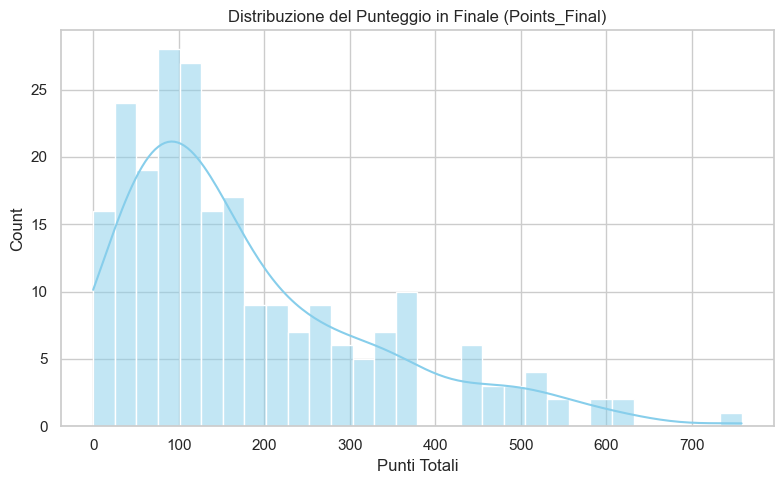

In [3]:
# Analisi Univariata di variabili target e predittori principali
plt.figure(figsize=(8, 5))

# Distribuzione del target continuo (Points_Final), filtrando i dati da predire del 2026
sns.histplot(df_master[df_master['Year'] < 2026]['Points_Final'], bins=30, kde=True, color='skyblue')
plt.title('Distribuzione del Punteggio in Finale (Points_Final)')
plt.xlabel('Punti Totali')

plt.tight_layout()
plt.show()

La distribuzione di `Points_Final` mostra una forte **asimmetria a destra**: la maggior parte dei finalisti ottiene punteggi medio-bassi, mentre solo pochi vincitori toccano valori molto alti (>500 punti). Questa coda lunga implica che modelli sensibili agli outlier (come l'OLS) potranno avere problemi: anticipa l'utilità della regolarizzazione e di metriche robuste.

### 3.2 Analisi bivariata vs qualificazione in finale

Per ciascuna delle 11 audio features generiamo un boxplot stratificato sul target binario `Grand_Final_Ind`. Se la mediana e/o lo spread di una feature differiscono tra qualificati (1) ed eliminati (0), allora quella feature può avere potere discriminativo e potrebbe essere un buon candidato come predittore.

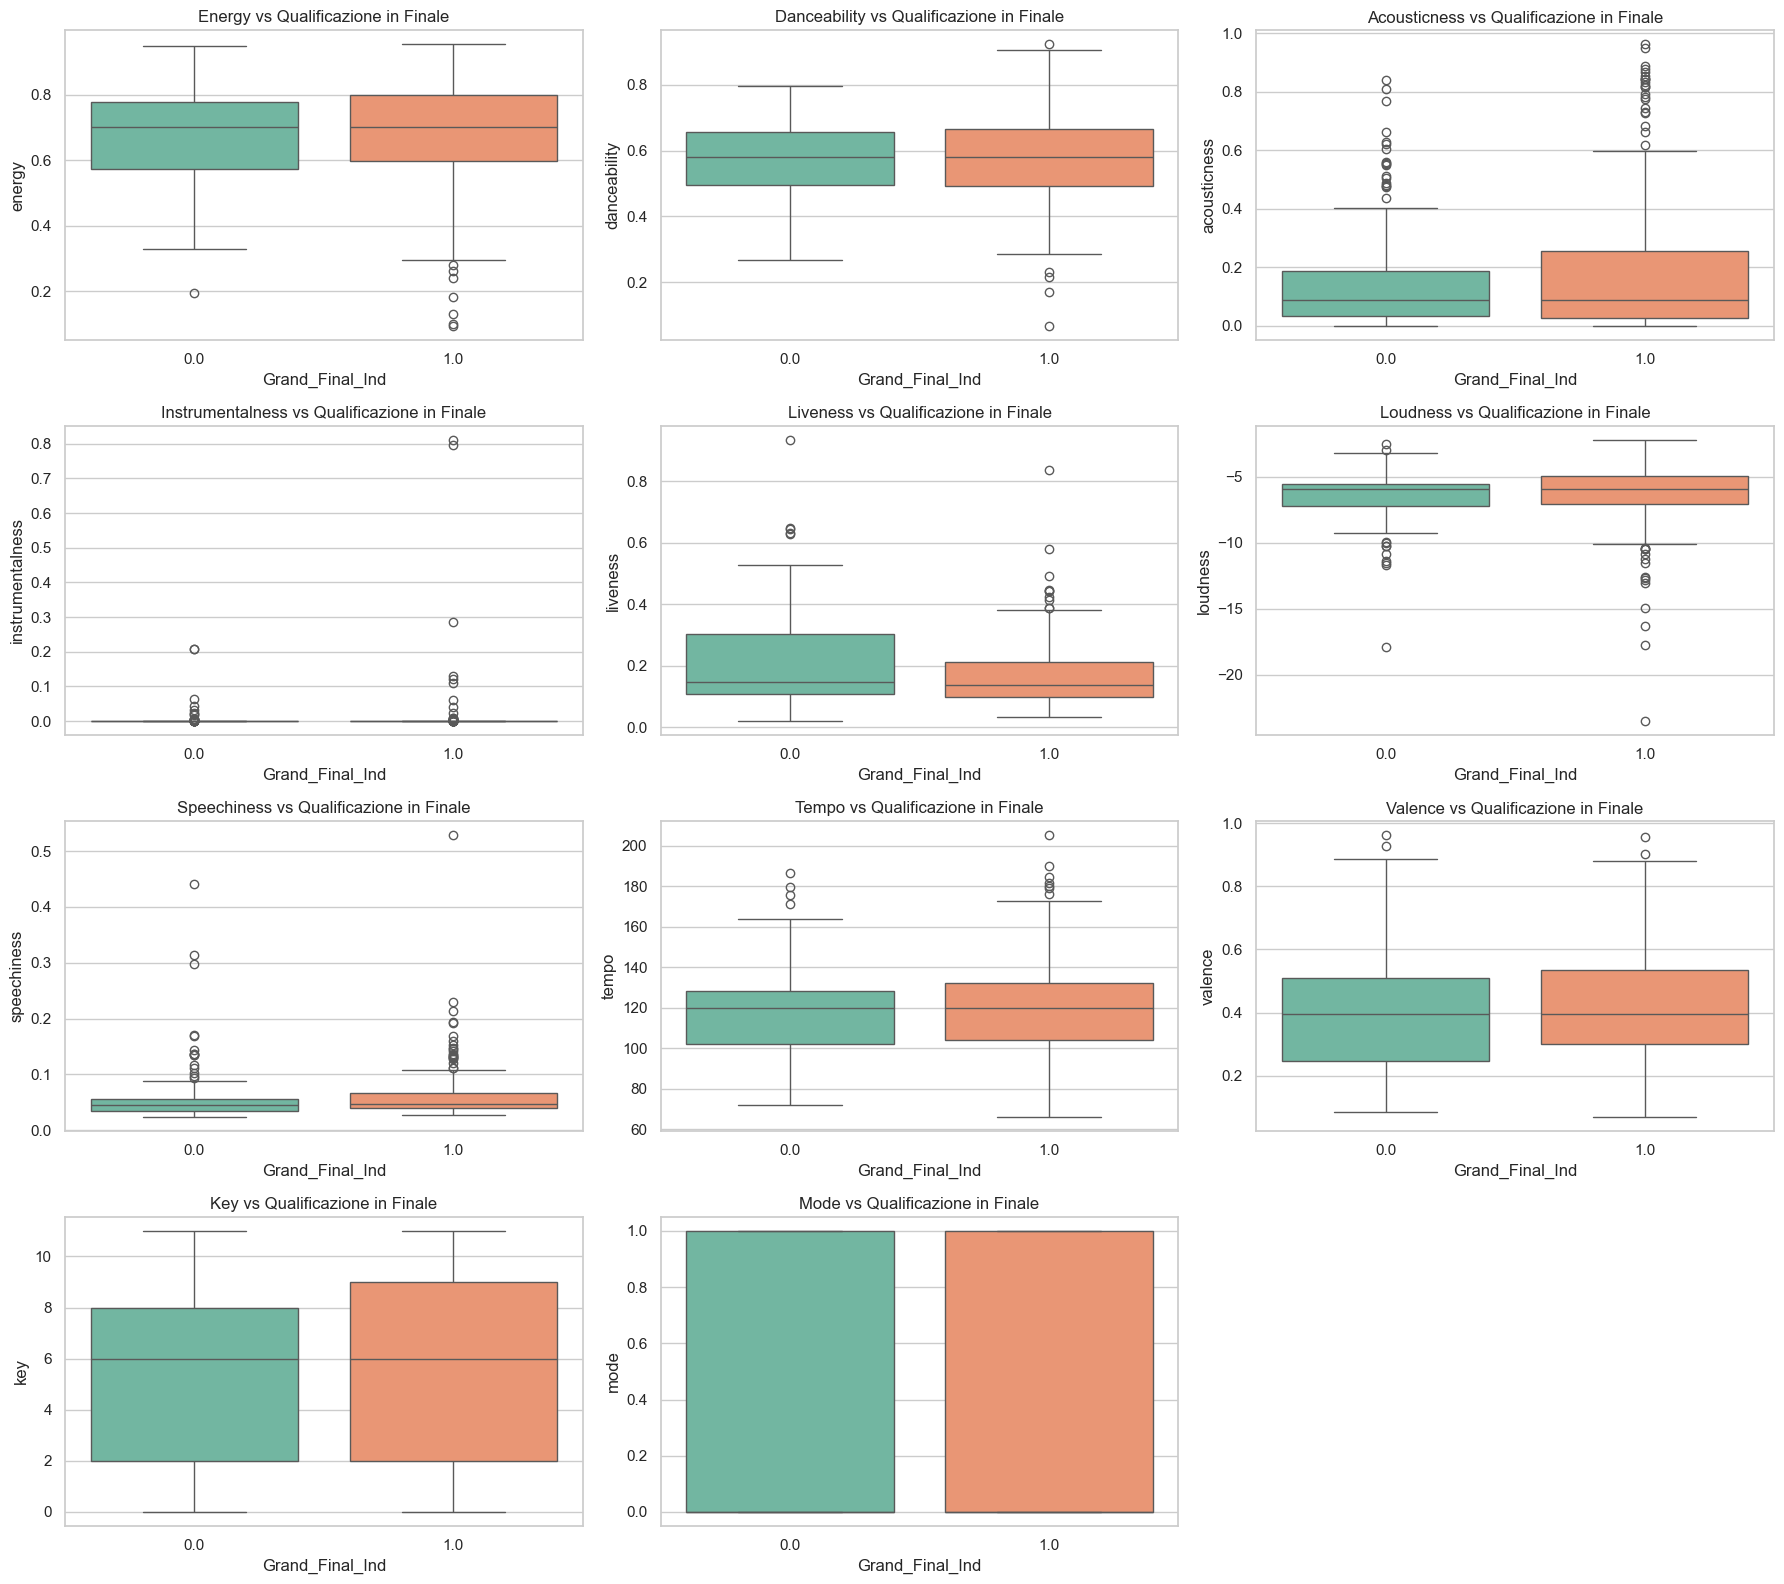

In [4]:
# Analisi Bivariata vs Qualificazione in Finale (Grand_Final_Ind)
fig, axes = plt.subplots(4, 3, figsize=(18, 16)) 

axes = axes.flatten()

sns.boxplot(x='Grand_Final_Ind', y='energy', data=df_master, ax=axes[0], palette='Set2')
axes[0].set_title('Energy vs Qualificazione in Finale')

sns.boxplot(x='Grand_Final_Ind', y='danceability', data=df_master, ax=axes[1], palette='Set2')
axes[1].set_title('Danceability vs Qualificazione in Finale')

sns.boxplot(x='Grand_Final_Ind', y='acousticness', data=df_master, ax=axes[2], palette='Set2')
axes[2].set_title('Acousticness vs Qualificazione in Finale')

sns.boxplot(x='Grand_Final_Ind', y='instrumentalness', data=df_master, ax=axes[3], palette='Set2')
axes[3].set_title('Instrumentalness vs Qualificazione in Finale') # Fixed index here

sns.boxplot(x='Grand_Final_Ind', y='liveness', data=df_master, ax=axes[4], palette='Set2')
axes[4].set_title('Liveness vs Qualificazione in Finale') # Adjusted indices below to match

sns.boxplot(x='Grand_Final_Ind', y='loudness', data=df_master, ax=axes[5], palette='Set2')
axes[5].set_title('Loudness vs Qualificazione in Finale')

sns.boxplot(x='Grand_Final_Ind', y='speechiness', data=df_master, ax=axes[6], palette='Set2')
axes[6].set_title('Speechiness vs Qualificazione in Finale')

sns.boxplot(x='Grand_Final_Ind', y='tempo', data=df_master, ax=axes[7], palette='Set2')
axes[7].set_title('Tempo vs Qualificazione in Finale')

sns.boxplot(x='Grand_Final_Ind', y='valence', data=df_master, ax=axes[8], palette='Set2')
axes[8].set_title('Valence vs Qualificazione in Finale')

sns.boxplot(x='Grand_Final_Ind', y='key', data=df_master, ax=axes[9], palette='Set2')
axes[9].set_title('Key vs Qualificazione in Finale')

sns.boxplot(x='Grand_Final_Ind', y='mode', data=df_master, ax=axes[10], palette='Set2')
axes[10].set_title('Mode vs Qualificazione in Finale')

axes[11].axis('off')

plt.tight_layout()
plt.show()

Le differenze più nette, ma comunque contenute, tra qualificati ed eliminati emergono su `loudness`e `acousticness`: i finalisti tendono ad avere valori mediamente più alti, suggerendo che i brani più "acustici" e "potenti" abbiano un vantaggio competitivo nelle semifinali. Variabili come `key` e `mode` mostrano invece distribuzioni molto sovrapposte: la tonalità del brano da sola non discrimina la qualificazione e contribuirà poco al modello.

### 3.3 Relazione audio features ↔ punteggio (solo finalisti)

Restringiamo l'analisi ai **finalisti reali** per investigare se, *condizionatamente al fatto di essere arrivati in finale*, le audio features predicono il punteggio totale. Visualizziamo scatter plot di ogni audio feature continua contro `Points_Final`.

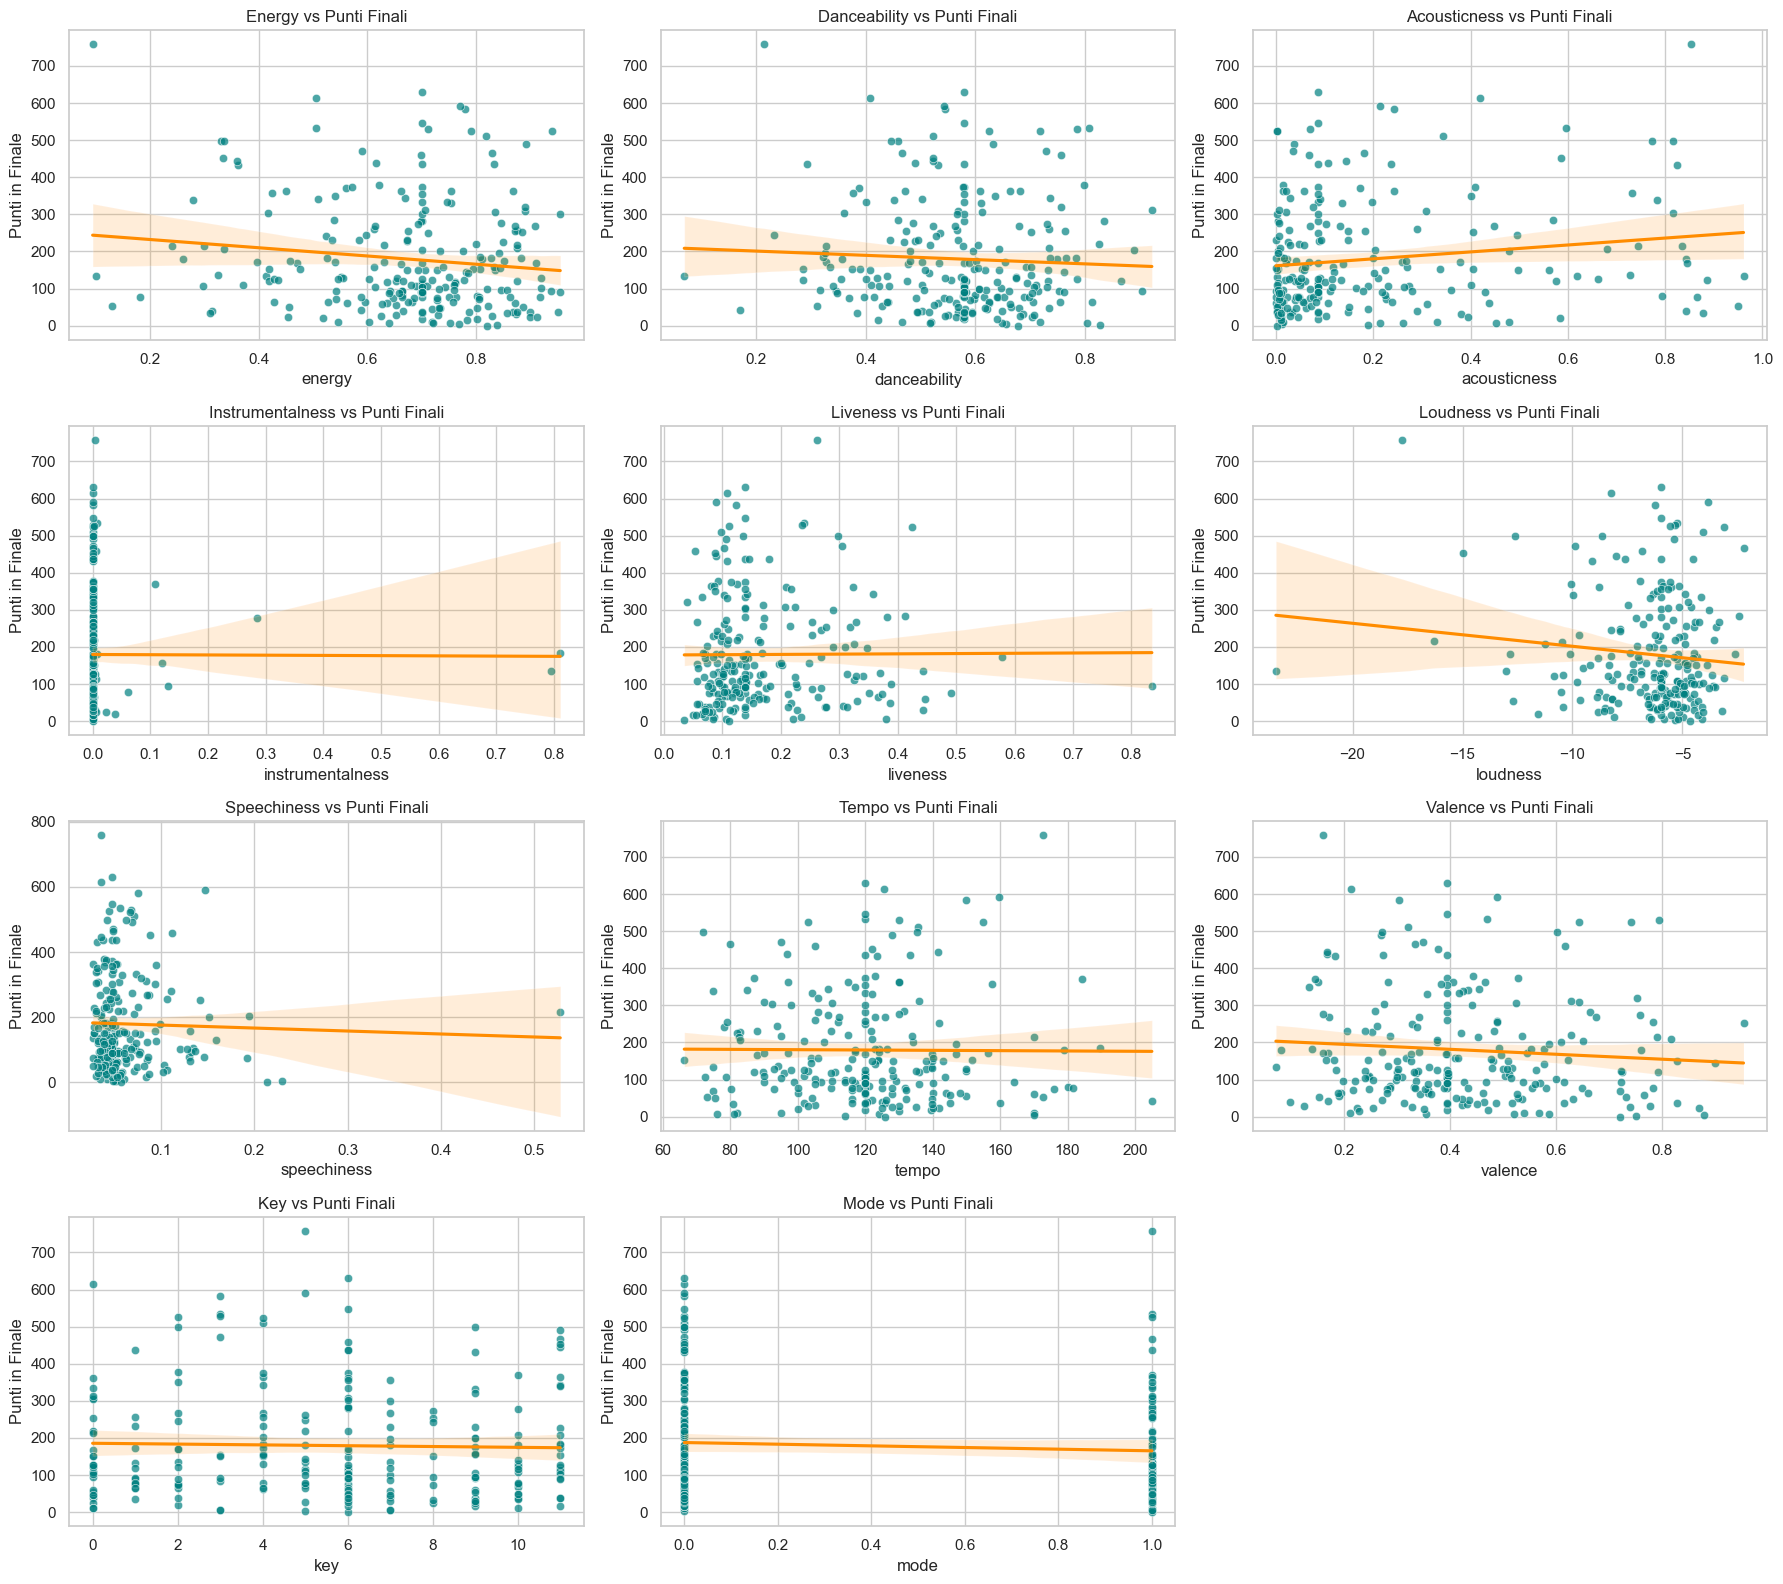

In [5]:
df_finalists = df_master[df_master['Grand_Final_Ind'] == 1].copy()

audio_features = [
    'energy', 'danceability', 'acousticness', 'instrumentalness', 
    'liveness', 'loudness', 'speechiness', 'tempo', 
    'valence', 'key', 'mode'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))

axes = axes.flatten()

for i, feature in enumerate(audio_features):
    sns.scatterplot(
        x=feature, 
        y='Points_Final', 
        data=df_finalists, 
        ax=axes[i], 
        color='teal', 
        alpha=0.7
        )
    
    sns.regplot(
        x=feature, 
        y='Points_Final', 
        data=df_finalists, 
        ax=axes[i], 
        scatter=False, 
        color='darkorange'
    )
    
    axes[i].set_title(f'{feature.capitalize()} vs Punti Finali')
    axes[i].set_ylabel('Punti in Finale')

axes[-1].axis('off')

plt.tight_layout()
plt.show()

Le nuvole di punti sono ampie e prive di trend lineari evidenti. Questo è coerente con la struttura del concorso: una volta in finale, contano molto di più la dimensione geopolitica e l'engagement della community pre-evento, mentre il "DNA musicale" del brano gioca un ruolo secondario nel determinare il punteggio esatto.

### 3.4 Distribuzione delle feature audio continue e categoriche

Esaminiamo la distribuzione di ciascuna delle 11 audio features in modo sistematico, distinguendo le **continue** dalle **categoriche**. Questa vista d'insieme serve a confermare la presenza di range coerenti, outlier sospetti, distribuzioni gaussiane o fortemente asimmetriche.

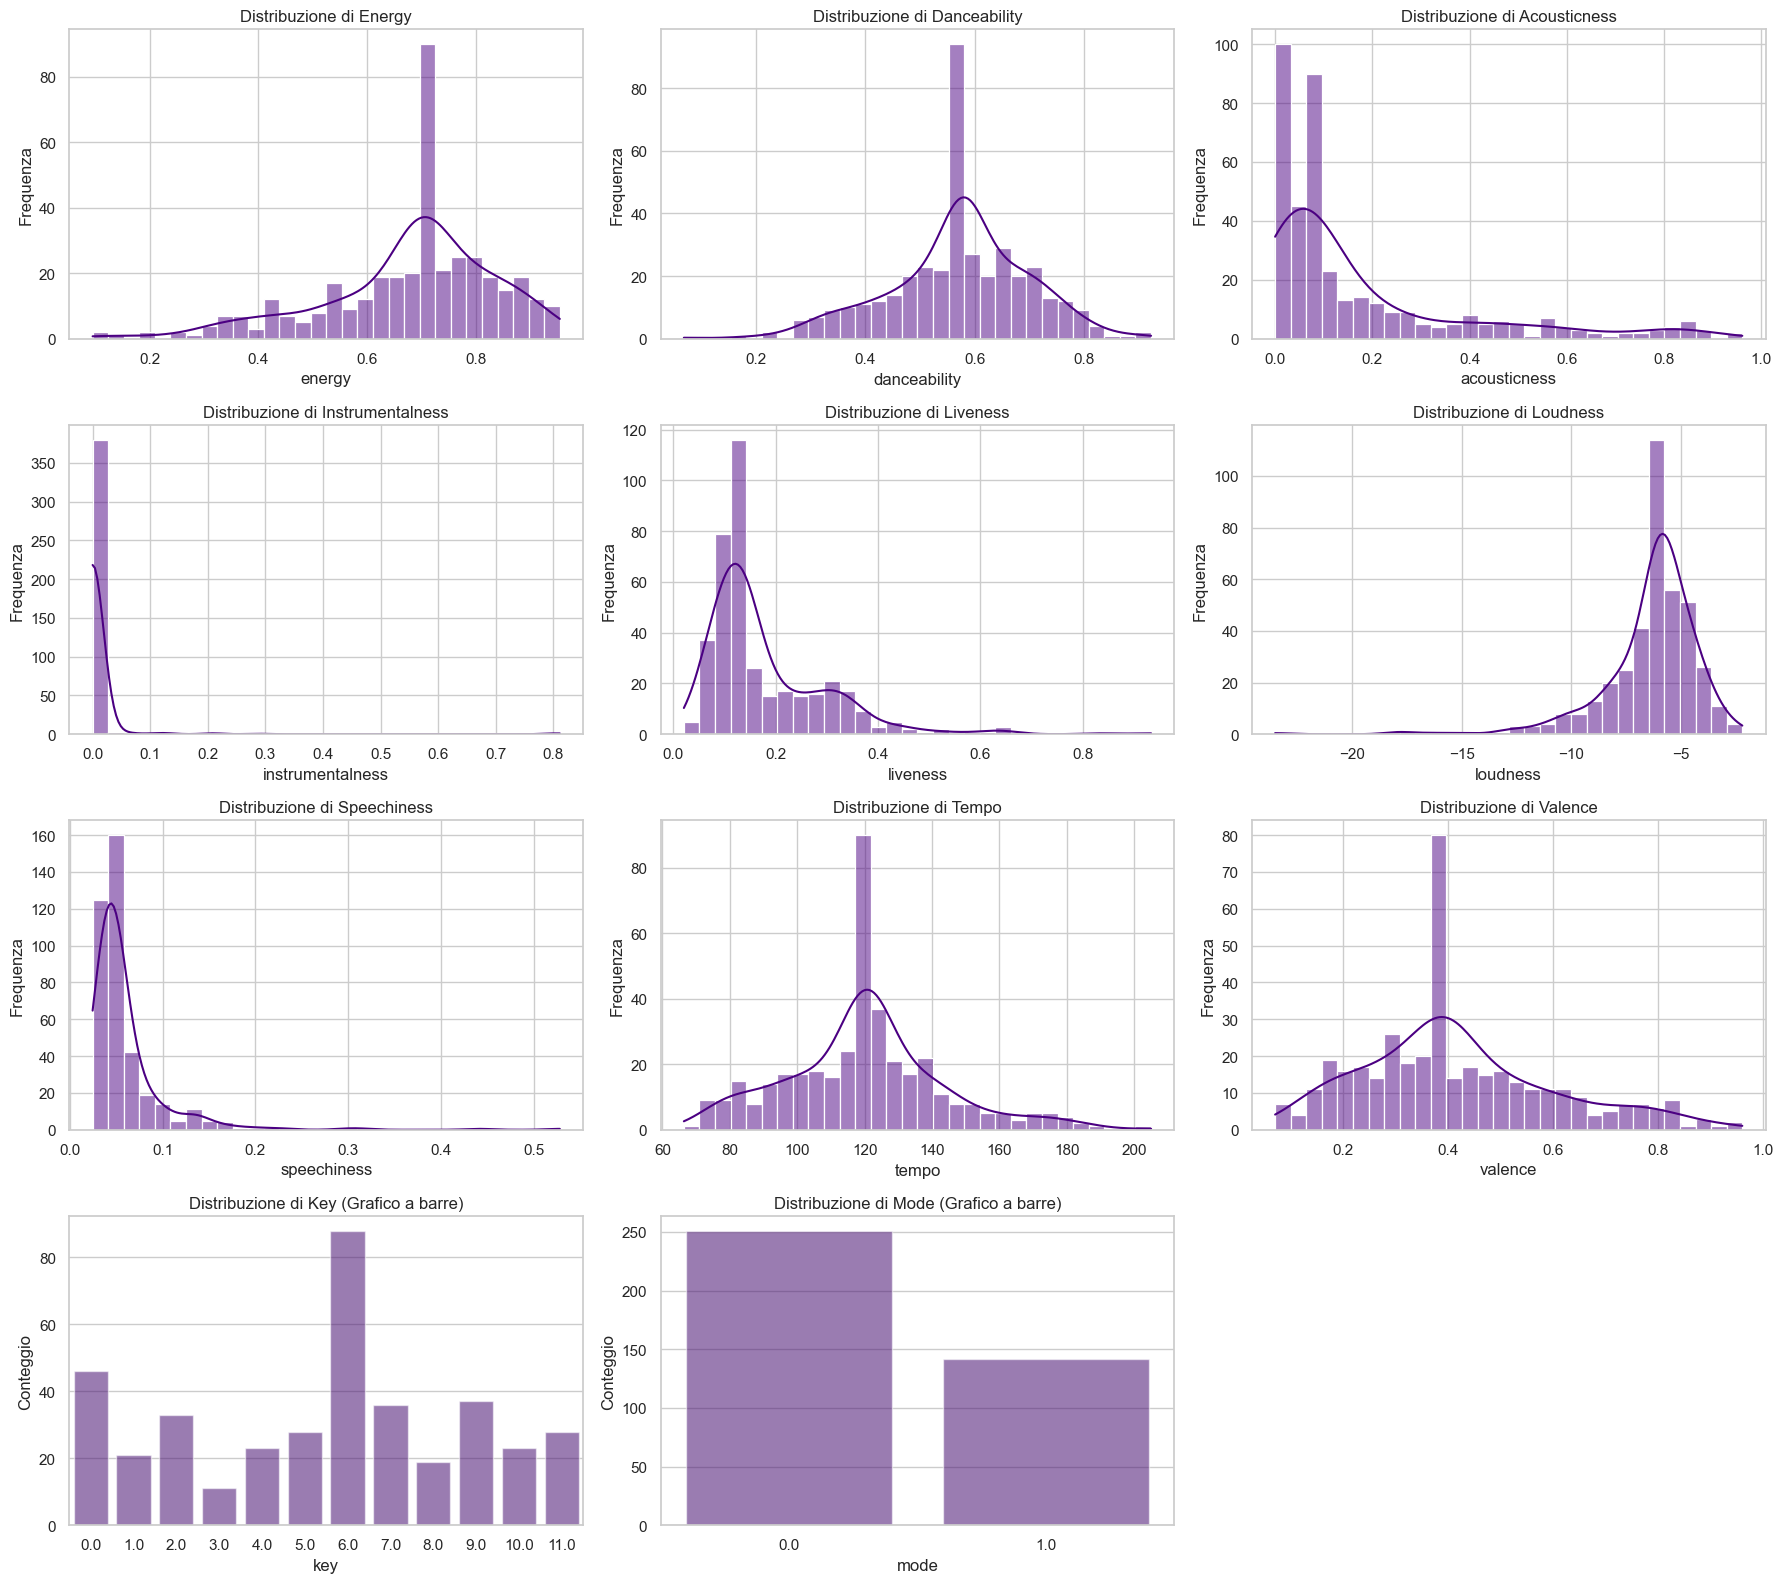

In [6]:
discrete_features = ['key', 'mode']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    if feature in discrete_features:
        sns.countplot(
            data=df_master, 
            x=feature, 
            ax=axes[i], 
            color='indigo', 
            alpha=0.55
        )
        axes[i].set_title(f'Distribuzione di {feature.capitalize()} (Grafico a barre)')
        axes[i].set_ylabel('Conteggio')
    else:
        sns.histplot(
            data=df_master, 
            x=feature, 
            kde=True, 
            ax=axes[i], 
            color='indigo', 
            bins=30
        )
        axes[i].set_title(f'Distribuzione di {feature.capitalize()}')
        axes[i].set_ylabel('Frequenza')
    
    axes[i].set_xlabel(feature)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

- **Spike centrali da imputazione.** I picchi anomali su `energy` (~0.70), `danceability` (~0.57), `loudness` (~−6 dB), `liveness` (~0.12), `tempo` (~120 BPM), `valence` (~0.40) e `key` (=6) sono l'impronta diretta dell'imputazione con mediana globale effettuata in fase di data cleaning sui brani non reperibili via API Spotify. È un artefatto noto e documentato, ma riduce la varianza informativa effettiva di queste feature e va tenuto presente nell'interpretazione dei coefficienti dei passaggi successivi.

- **Asimmetrie a destra.** `acousticness`, `instrumentalness`, `liveness` e `speechiness` sono fortemente concentrate vicino a zero, in linea con la natura del repertorio Eurovision: brani quasi sempre cantati (`instrumentalness` ≈ 0), prevalentemente in produzione studio elettronico-pop (`acousticness` e `liveness` basse), senza componenti parlate (`speechiness` bassa).

- **Asimmetria a sinistra di `loudness`.** Massa concentrata tra −8 e −4 dB con coda lunga verso valori più bassi: è la firma della *loudness war* della produzione pop moderna, che livella verso l'alto il volume percepito dei brani in gara.

Le audio features sono utilizzabili ma non sono sufficienti da sole: la loro variabilità è limitata e in parte artificiale, il che giustifica a posteriori la scelta progettuale di affiancarle a feature storiche, gravitazionali e di fan-engagement (`OGAE_Points`, `MyESB_Community`), e motiva l'impiego di Ridge e Lasso per gestire la multicollinearità e la sparsità di segnale tipiche di questo blocco di predittori.


### 3.5 Audience pressure: OGAE e MyESB Community vs qualificazione

Confrontiamo la distribuzione di due indicatori di **popolarità pre-show** rispetto al passaggio in finale:
- `OGAE_Points`: voti dai fan club ufficiali Eurovision di tutta Europa, raccolti prima del contest;
- `MyESB_Community`: ranking aggregato dell'app "My Eurovision Scoreboard" basato sul giudizio della community internazionale.

Se queste metriche separano nettamente qualificati ed eliminati, sono predittori forti di sopravvivenza alla semifinale.

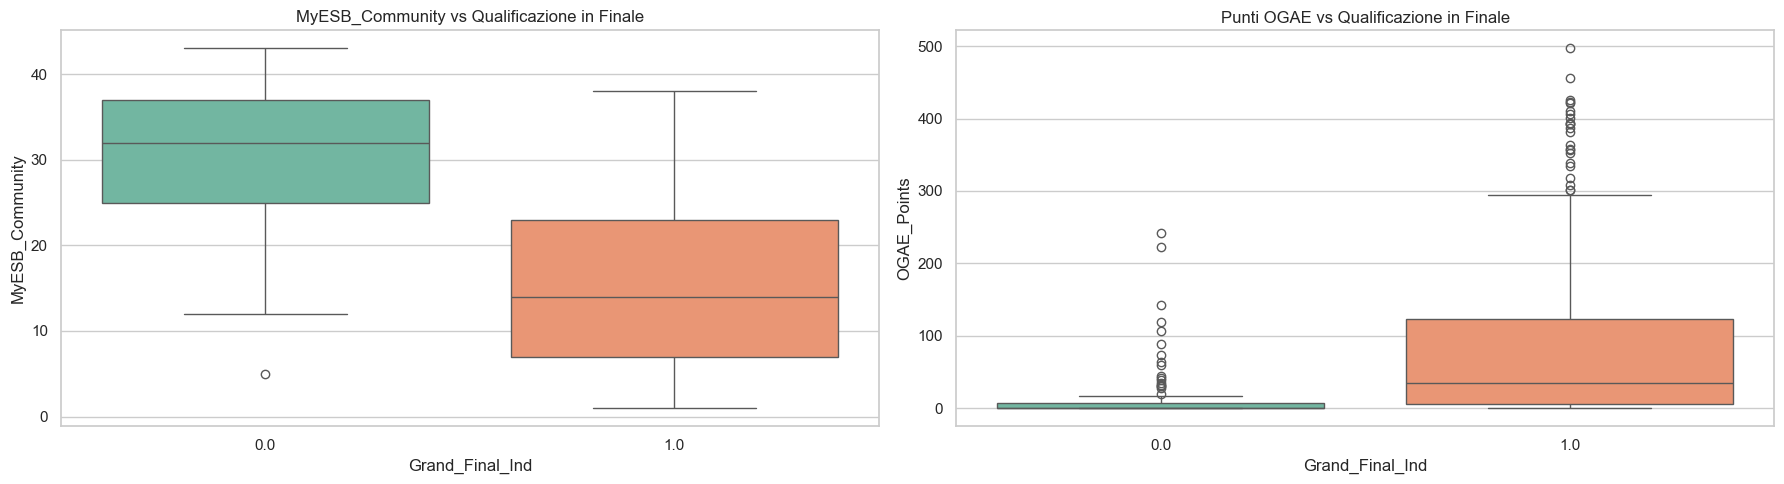

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Limitiamo OGAE per una migliore visualizzazione rimuovendo estremi outlier
sns.boxplot(x='Grand_Final_Ind', y='MyESB_Community', data=df_master, ax=axes[0], palette='Set2') 
axes[0].set_title('MyESB_Community vs Qualificazione in Finale')

sns.boxplot(x='Grand_Final_Ind', y='OGAE_Points', data=df_master, ax=axes[1], palette='Set2') 
axes[1].set_title('Punti OGAE vs Qualificazione in Finale')

plt.tight_layout()
plt.show()

La separazione è **evidente**:
- I qualificati hanno mediana di `OGAE_Points` molto più alta degli eliminati (con poca sovrapposizione tra i box).
- I qualificati hanno `MyESB_Community` ranking molto più basso (= migliore) degli eliminati.

Le community OGAE/MyESB anticipano in modo affidabile il risultato della semifinale: questo spiega perché queste due variabili domineranno i coefficienti di tutti i modelli, anche dopo la feature selection di Lasso.

### 3.6 Matrice di correlazione delle audio features

Calcoliamo e visualizziamo la matrice di correlazione di Pearson tra le 11 audio features. La presenza di correlazioni > 0.6 in valore assoluto è un campanello d'allarme per l'**OLS** (la cui stima diventa instabile con feature collineari) e una **giustificazione formale** per l'introduzione di metodi di regolarizzazione.

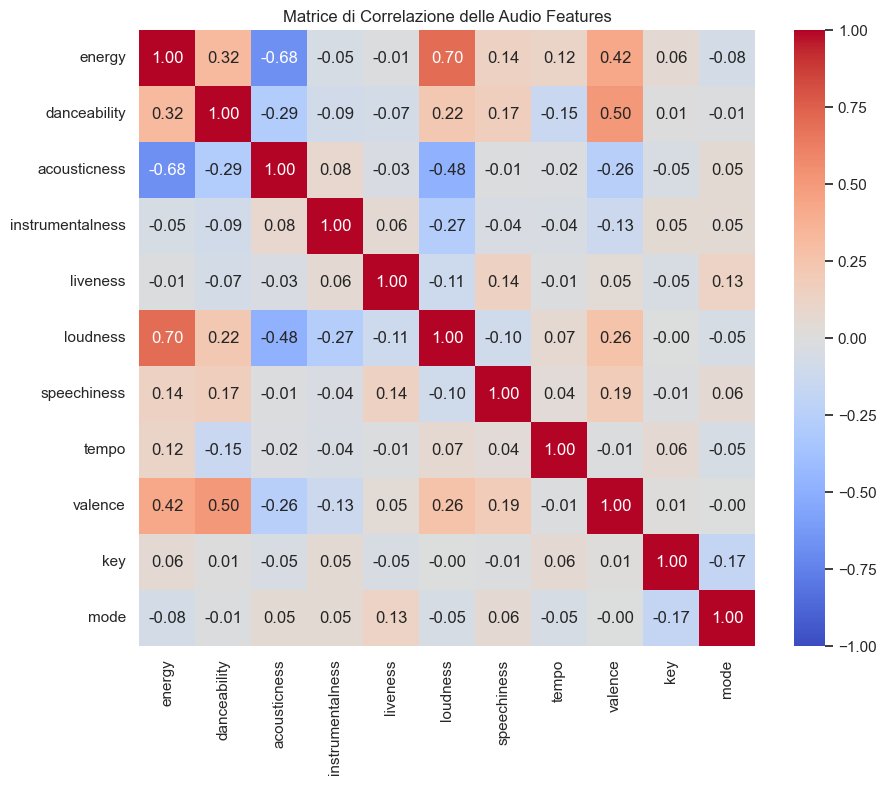

In [8]:
corr_matrix = df_master[audio_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matrice di Correlazione delle Audio Features')
plt.show()

Emergono due correlazioni sistematiche:
- **`energy` ↔ `loudness`** ≈ +0.70: i brani ad alta energia sono anche più sonori. È un classico esempio di ridondanza, da regolarizzare.
- **`energy` ↔ `acousticness`** ≈ -0.68: relazione inversa attesa (più un brano è acustico, meno è energico).

### 3.7 Leaderboard storica
Una heatmap `Country × Year` con il piazzamento finale come valore racconta in
un colpo d'occhio la storia recente dell'Eurovision: blocchi verdi = nazioni
con risultati costantemente alti; blocchi rossi = piazzamenti bassi; celle
bianche = paese non qualificato/non partecipante in quell'anno.
Affianchiamo una tabella riassuntiva per nazione (partecipazioni, qualification
rate, posizionamento medio, miglior risultato): è la base empirica che
giustifica la costruzione della fase di features engineering.

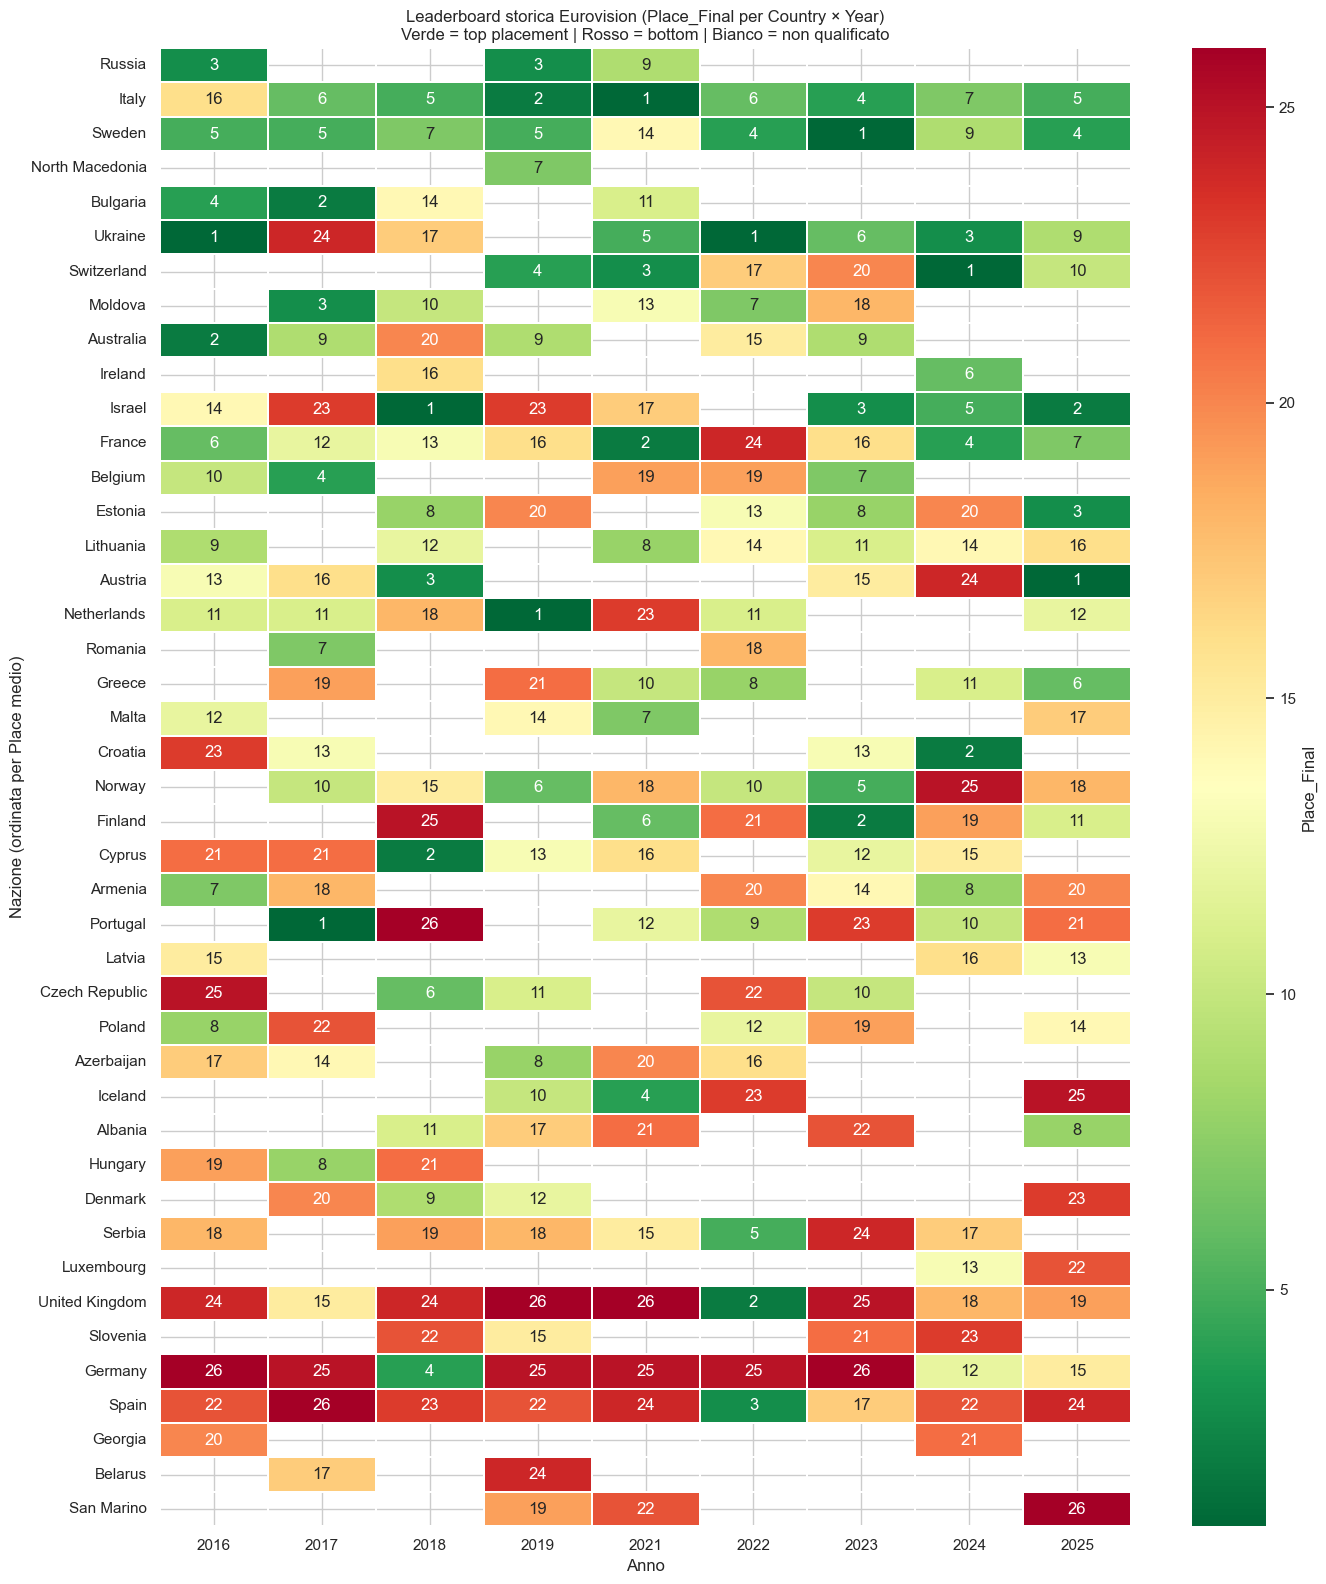

In [9]:
df_lb = df_master[(df_master['Year'] >= 2016) & (df_master['Year'] <= 2025)].copy()

heatmap_data = df_lb.pivot_table(
    index='Country', columns='Year', values='Place_Final', aggfunc='first'
)

heatmap_data['avg_place'] = heatmap_data.mean(axis=1, skipna=True)
heatmap_data = heatmap_data.sort_values('avg_place').drop(columns='avg_place')

plt.figure(figsize=(14, 16))
sns.heatmap(
    heatmap_data, annot=True, fmt='.0f',
    cmap='RdYlGn_r',          
    cbar_kws={'label': 'Place_Final'},
    linewidths=0.3, linecolor='white'
)
plt.title('Leaderboard storica Eurovision (Place_Final per Country × Year)\n'
          'Verde = top placement | Rosso = bottom | Bianco = non qualificato')
plt.xlabel('Anno')
plt.ylabel('Nazione (ordinata per Place medio)')
plt.tight_layout()
plt.show()

L'ordinamento per piazzamento medio mette in evidenza i "magneti" del contest negli ultimi 10 anni:
- **Russia, Italia e Svezia** dominano la top-3 con piazzamenti medi inferiori a 8;
- l'Italia ha avuto un'esplosione post-2017, con una serie ininterrotta di top-10;

I blocchi rossi/bianchi nelle code della tabella identificano nazioni "sentinella" (San Marino, Slovenia, Macedonia del Nord) per cui il modello dovrà essere conservativo nelle predizioni di top-placement.

In [10]:
# Tabella riassuntiva storica per nazione

df_country = df_lb.groupby('Country').agg(
    Partecipazioni=('Year', 'nunique'),
    Anni_in_Semifinale=('Big6_Ind', lambda x: (x == 0).sum()),
    Qualificazioni=('Grand_Final_Ind', 'sum'),
    Place_Medio=('Place_Final', 'mean'),
    Place_Mediano=('Place_Final', 'median'),
    Punti_Medi=('Points_Final', 'mean'),
    Miglior_Risultato=('Place_Final', 'min'),
    Punteggio_Massimo=('Points_Final', 'max'),
).round(2)

df_country['Qualification_Rate'] = np.where(
    df_country['Anni_in_Semifinale'] > 0,
    (df_country['Qualificazioni'] / df_country['Anni_in_Semifinale']).round(2),
    np.nan  # Big-6: rate non definito
)

df_country = df_country.sort_values(['Miglior_Risultato', 'Place_Medio'])

print('Top 15 nazioni per ranking storico (2016–2025):')
print(df_country.head(15).to_string())
print('\nBottom 10 nazioni per ranking storico:')
print(df_country.tail(10).to_string())

Top 15 nazioni per ranking storico (2016–2025):
                Partecipazioni  Anni_in_Semifinale  Qualificazioni  Place_Medio  Place_Mediano  Punti_Medi  Miglior_Risultato  Punteggio_Massimo  Qualification_Rate
Country                                                                                                                                                             
Italy                        9                   0             9.0         5.78            5.0      322.67                1.0              524.0                 NaN
Sweden                       9                   7             9.0         6.00            5.0      315.33                1.0              583.0                1.29
Ukraine                      8                   6             8.0         8.25            5.5      326.12                1.0              631.0                1.33
Switzerland                  9                   8             6.0         9.17            7.0      295.17                1.0  

I primi 15 paesi confermano e quantificano l'evidenza visiva della heatmap:
- **Italia** è prima con piazzamento medio 5.78 e 9 qualificazioni su 9 partecipazioni;
- **Svezia, Ucraina e Svizzera** seguono con piazzamenti medi sotto 10;
- nazioni come **Bulgaria** e **Portogallo** mostrano picchi notevoli (vincitori una tantum) ma media meno brillante;
- alcuni paesi hanno `Qualification_Rate > 1`: è un artefatto numerico (il loro storico include anni in cui partecipano sia in semifinale che alla finale come ex-vincitori), non un errore.

Questa tabella è la **base empirica** che giustifica la costruzione delle features legate alla forza storica: la concentrazione del successo su poche nazioni è statisticamente robusta e può essere sfruttata come predittore.

### 3.8 Esplorazione del voting bilaterale

Analizziamo il dataset `eurovision_voting_master.xlsx` da due angolature:
- **heatmap dei voti medi** sender → receiver, per visualizzare i blocchi votanti;
- **top-5 sostenitori storici** per ciascun receiver, supporto empirico delle Gravity Features;

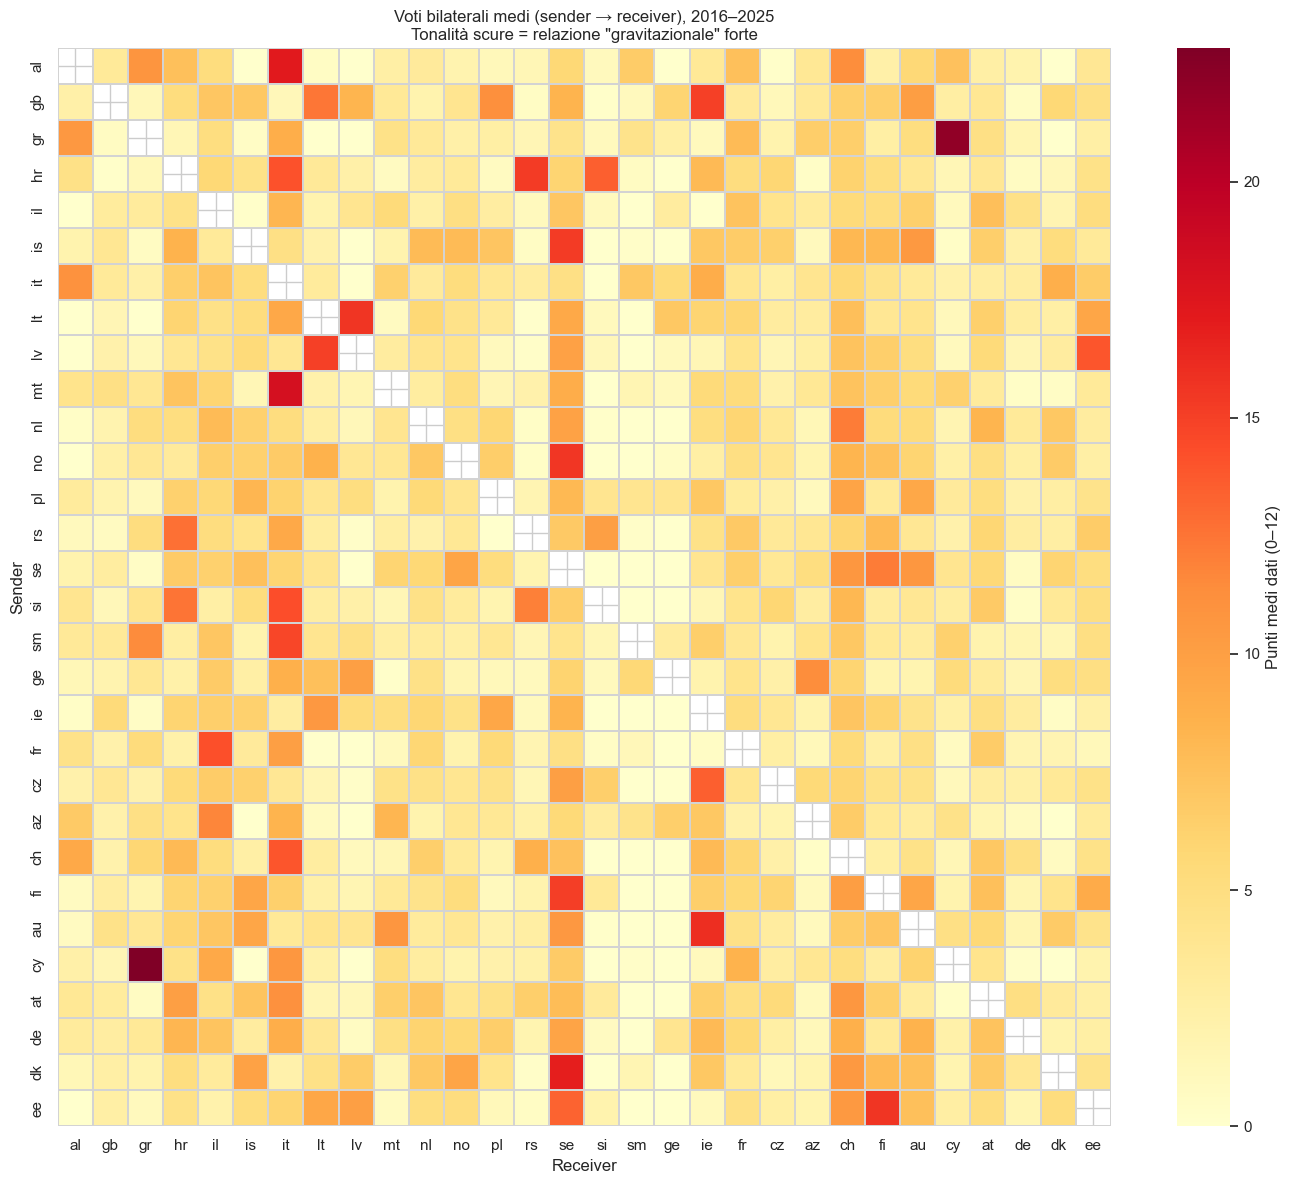

In [11]:
# Heatmap dei voti bilaterali medi (sender → receiver)

df_voting.columns = [c.lower() for c in df_voting.columns]

# Punti medi dati da ogni sender a ogni receiver, mediati su tutti gli anni
voting_avg = (df_voting
              .groupby(['sender_code', 'receiver_code'])['points']
              .mean()
              .reset_index())

voting_pivot = voting_avg.pivot(
    index='sender_code', columns='receiver_code', values='points'
)

top_countries = (df_voting.groupby('sender_code')['year']
                 .nunique().sort_values(ascending=False).head(30).index.tolist())
mask_idx = [c for c in top_countries if c in voting_pivot.index]
mask_col = [c for c in top_countries if c in voting_pivot.columns]
voting_pivot_top = voting_pivot.loc[mask_idx, mask_col]

plt.figure(figsize=(14, 12))
sns.heatmap(voting_pivot_top, cmap='YlOrRd',
            cbar_kws={'label': 'Punti medi dati (0–12)'},
            linewidths=0.2, linecolor='lightgray')
plt.title('Voti bilaterali medi (sender → receiver), 2016–2025\n'
          'Tonalità scure = relazione "gravitazionale" forte')
plt.xlabel('Receiver')
plt.ylabel('Sender')
plt.tight_layout()
plt.show()

**Lettura della heatmap.** Anche senza ordinare le nazioni, emergono **bande diagonali colorate** che corrispondono ai blocchi votanti classici della letteratura Eurovision: il blocco nordico (Svezia–Norvegia–Danimarca–Finlandia–Islanda), quello ex-jugoslavo (Serbia–Croazia–Slovenia–Bosnia–Macedonia), quello mediterraneo (Italia–Malta–San Marino–Cipro–Grecia) e quello ex-URSS (Russia–Ucraina–Bielorussia–Moldova). Queste bande sono il fenomeno empirico che le Gravity Features cercano di catturare in modo strutturale.

In [12]:
# Top-5 sostenitori storici per receiver

top5 = (df_voting.groupby(['receiver_code', 'sender_code'])['points']
        .mean().reset_index()
        .sort_values(['receiver_code', 'points'], ascending=[True, False])
        .groupby('receiver_code').head(5))

nazioni_focus = ['it', 'se', 'gr', 'ua', 'il', 'gb', 'cy', 'rs', 'fi']
for naz in nazioni_focus:
    blocco = top5[top5['receiver_code'] == naz]
    if len(blocco):
        print(f"\n>>> Top-5 sostenitori storici di {naz.upper()}")
        print(blocco[['sender_code', 'points']]
              .rename(columns={'sender_code': 'da', 'points': 'punti_medi'})
              .to_string(index=False))


>>> Top-5 sostenitori storici di IT
da  punti_medi
mt   18.222222
al   17.222222
sm   14.666667
si   14.333333
hr   14.111111

>>> Top-5 sostenitori storici di SE
da  punti_medi
dk   16.888889
no   15.555556
is   15.333333
fi   15.111111
ee   13.333333

>>> Top-5 sostenitori storici di GR
da  punti_medi
cy   22.833333
bg   13.000000
sm   11.500000
al   10.833333
ru    8.500000

>>> Top-5 sostenitori storici di UA
da  punti_medi
ba   19.000000
md   16.142857
pl   15.000000
cz   14.625000
il   14.375000

>>> Top-5 sostenitori storici di IL
 da  punti_medi
 fr       14.25
 lu       12.50
wld       12.00
 az       11.75
 cy        9.25

>>> Top-5 sostenitori storici di GB
da  punti_medi
ie    5.444444
ua    4.750000
mt    4.666667
au    4.444444
is    3.777778

>>> Top-5 sostenitori storici di CY
da  punti_medi
gr   22.000000
am   11.500000
ru   11.000000
al    7.428571
lu    7.000000

>>> Top-5 sostenitori storici di RS
da  punti_medi
me   22.500000
ba   20.000000
mk   18.600000
hr   15.

- **Italia** riceve i suoi voti più alti da Malta, Albania, San Marino, Slovenia, Croazia → blocco mediterraneo + diaspora;
- **Svezia** dai paesi nordici (Danimarca, Norvegia, Islanda, Finlandia, Estonia);
- **Grecia** dominata da Cipro (22.8 punti medi, di gran lunga il valore più alto della tabella) → "voto familiare";
- **Serbia** dai paesi ex-jugoslavi (Montenegro, Bosnia, Macedonia, Croazia, Slovenia);
- **Regno Unito** invece riceve in media meno di 6 punti dai suoi top supporter, riflettendo il famoso "isolamento" britannico nel voto Eurovision.

Queste relazioni bilaterali sono il segnale che le Gravity Features proveranno a sintetizzare in modo aggregato e dinamico.

### OGAE Points e MyESB
`OGAE_Points` e `MyESB_Community` sono indicatori di
**popolarità pre-show** raccolti tra fan club e siti specializzati prima della
finale.

Verifichiamo:
- se OGAE e MyESB sono ridondanti tra loro (info simile → multicollinearità);
- se la separazione qualificati/non-qualificati è netta su queste metriche.

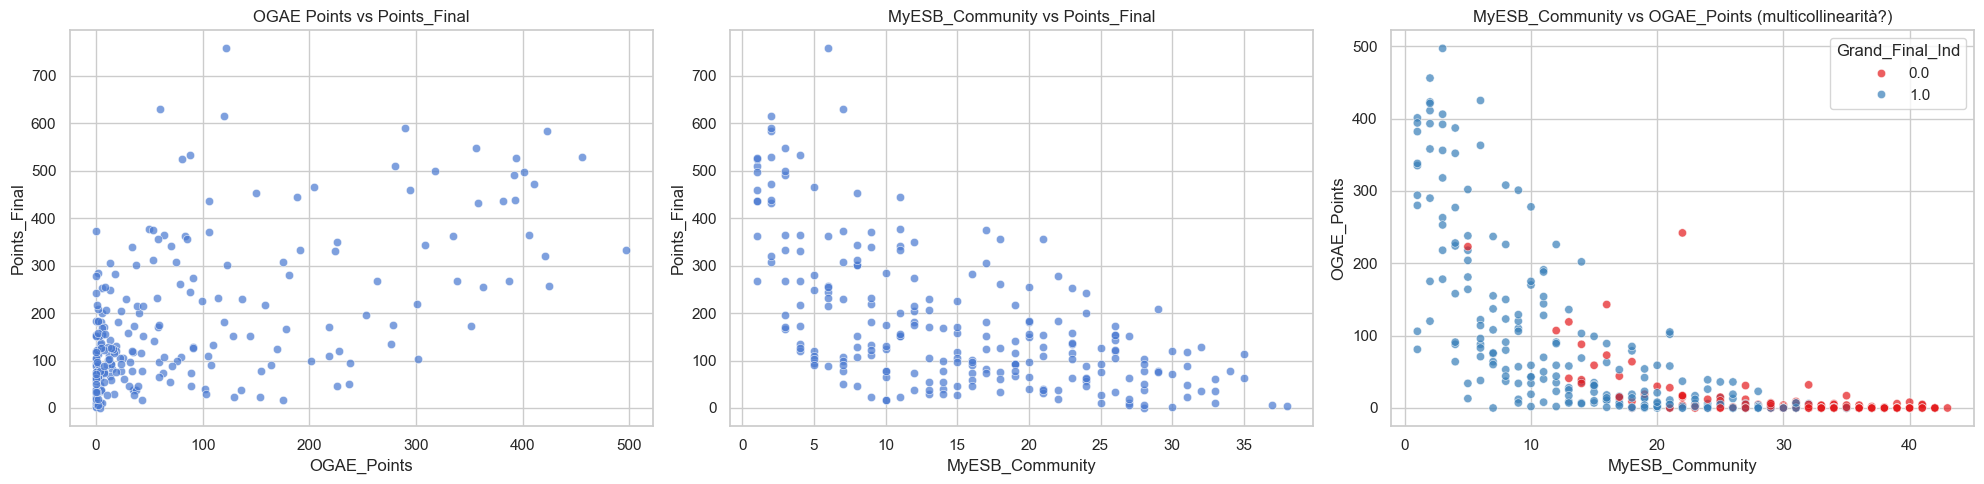

Correlazione delle metriche audience-pressure con Points_Final:
  OGAE_Points       : Pearson r = +0.562 (p=0.000) | N = 232
  MyESB_Community   : Pearson r = -0.596 (p=0.000) | N = 232


In [13]:
from scipy.stats import pearsonr

df_aud = df_master[df_master['Year'] < 2026].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.scatterplot(x='OGAE_Points', y='Points_Final',
                data=df_aud, ax=axes[0], alpha=0.7, palette='Set1')
axes[0].set_title('OGAE Points vs Points_Final')

sns.scatterplot(x='MyESB_Community', y='Points_Final',
                data=df_aud, ax=axes[1], alpha=0.7, palette='Set1')
axes[1].set_title('MyESB_Community vs Points_Final')

sns.scatterplot(x='MyESB_Community', y='OGAE_Points',
                hue='Grand_Final_Ind', data=df_aud, ax=axes[2],
                alpha=0.7, palette='Set1')
axes[2].set_title('MyESB_Community vs OGAE_Points (multicollinearità?)')
plt.tight_layout()
plt.show()

print('Correlazione delle metriche audience-pressure con Points_Final:')
for col in ['OGAE_Points', 'MyESB_Community']:
    if col in df_aud.columns:
        sub = df_aud[[col, 'Points_Final']].dropna()
        if len(sub) > 5:
            r_p, p_p = pearsonr(sub[col], sub['Points_Final'])
            print(f'  {col:18s}: Pearson r = {r_p:+.3f} (p={p_p:.3f}) | N = {len(sub)}')

Le correlazioni con `Points_Final` confermano l'enorme potere predittivo:
- **OGAE_Points**: Pearson r = +0.562 (p < 0.001) — relazione monotona positiva forte;
- **MyESB_Community**: Pearson r = -0.596 (p < 0.001) — relazione monotona **negativa**  altrettanto forte;

La matrice di correlazione interna mostra che **OGAE e MyESB_Community sono fortemente ridondanti** (ρ = -0.84): predicono lo stesso fenomeno (la popolarità pre-show).

## 4. Fase 2 — Feature Engineering e Data Splitting

In questa fase arricchiamo il dataset con due nuove famiglie di feature che catturano dimensioni assenti nel master originale:
- **Forza Storica**: il "pedigree" di un paese all'Eurovision (medie di punteggi e piazzamenti, tasso di qualificazione).
- **Gravity Features (CEPII)**: il vantaggio strutturale di un paese in una specifica edizione, calcolato sui votanti effettivamente presenti quell'anno.

Tutte le aggregazioni sono costruite prevenendo data leakage: per l'anno *t*, ogni feature usa esclusivamente informazioni disponibili al massimo all'anno *t-1*. Senza questa precauzione le metriche di validazione sarebbero ottimisticamente gonfiate e il modello collasserebbe in produzione.

### 4.1 Forza Storica (Historical Features)

Calcoliamo per ogni nazione, anno per anno, tre metriche storiche aggregate sulle ultime edizioni:
- `Historical_Avg_Points_Last5`: media mobile (rolling 5) dei punti finali storici;
- `Historical_Avg_Placement`: piazzamento medio storico nelle ultime 5 edizioni;
- `Historical_Qual_Ratio`: tasso cumulativo Qualificazioni/Partecipazioni.

L'uso di `groupby('Country').shift(1)` garantisce che, per l'anno *t*, ogni metrica si riferisca **solo** ai dati ≤ *t-1*. I nuovi entranti (privi di storico) vengono imputati con la mediana globale per evitare NaN nei modelli lineari.

In [14]:
# Ordiniamo rigorosamente per nazione e per anno per garantire che lo shift temporale sia corretto
df_master = df_master.sort_values(['Country', 'Year']).reset_index(drop=True)

# Media Punti Finali storici (ultime 5 edizioni)
df_master['Points_Final_shift'] = df_master.groupby('Country')['Points_Final'].shift(1)
df_master['Historical_Avg_Points_Last5'] = df_master.groupby('Country')['Points_Final_shift'].transform(lambda x: x.rolling(5, min_periods=1).mean())

# Piazzamento Medio Finale storico
df_master['Place_Final_shift'] = df_master.groupby('Country')['Place_Final'].shift(1)
df_master['Historical_Avg_Placement'] = df_master.groupby('Country')['Place_Final_shift'].transform(lambda x: x.rolling(5, min_periods=1).mean())

# Rapporto Qualificazioni / Partecipazioni (Cumulative ratio)
df_master['Grand_Final_Ind_shift'] = df_master.groupby('Country')['Grand_Final_Ind'].shift(1)
df_master['Cum_Qual'] = df_master.groupby('Country')['Grand_Final_Ind_shift'].cumsum()
df_master['Cum_Participations'] = df_master.groupby('Country')['Grand_Final_Ind_shift'].transform(lambda x: (~x.isna()).cumsum())
df_master['Historical_Qual_Ratio'] = df_master['Cum_Qual'] / df_master['Cum_Participations']

# Pulizia
df_master.drop(columns=['Points_Final_shift', 'Place_Final_shift', 'Grand_Final_Ind_shift', 'Cum_Qual', 'Cum_Participations'], inplace=True)

# Imputazione dei valori storici mancanti
# Utilizziamo la mediana globale per non introdurre bias estremi
for col in ['Historical_Avg_Points_Last5', 'Historical_Avg_Placement', 'Historical_Qual_Ratio']:
    df_master[col] = df_master[col].fillna(df_master[col].median())

### 4.2 Gravity Features (CEPII)

La geo-politica gioca un ruolo strutturale nelle dinamiche di voto Eurovision. Per quantificarlo introduciamo le **Gravity Features**, ispirate al *Gravity Model of Trade* della letteratura economica internazionale: l'interazione tra due nazioni è proporzionale alla loro "massa" e inversamente proporzionale alla loro "distanza" geografica, culturale o storica.

Il calcolo è **dinamico anno per anno** poiché il bacino dei votanti effettivamente presenti cambia ogni edizione. Per ciascun anno *t* e ciascun paese ricevente costruiamo:

- `Gravity_Contig_Voters`: numero di stati confinanti effettivamente in gara nell'edizione *t* (voto di vicinato);
- `Gravity_Comlang_Voters`: numero di stati con lingua ufficiale comune in gara nell'edizione *t*;
- `Gravity_Colony_Voters`: numero di stati in gara con cui condivide legami coloniali storici;
- `Gravity_Proximity_Index`: somma di $1/\text{distw}$ pesata sui partecipanti reali - alto valore = molti vicini geografici in gara.

In [15]:
gravity_features = []

for year in df_master['Year'].unique():
    # Identifichiamo il pool di paesi partecipanti (votanti) per l'anno t
    participants_year = df_master[df_master['Year'] == year]['iso3'].dropna().unique()
    
    for receiver in participants_year:
        # I votanti possibili sono tutti tranne se stesso
        senders = [s for s in participants_year if s != receiver]
        
        # Filtriamo il dataset CEPII per questo ricevente e i relativi mittenti
        dist_subset = df_dist[(df_dist['iso_d'] == receiver) & (df_dist['iso_o'].isin(senders))]
        
        if not dist_subset.empty:
            contig = dist_subset['contig'].sum()           # N. di stati confinanti che votano
            comlang = dist_subset['comlang_off'].sum()     # N. di stati con lingua comune
            colony = dist_subset['colony'].sum()           # N. di stati con legami coloniali
            
            # Indice di Prossimità Gravitazionale (somma dell'inverso della distanza pesata)
            dist_inv_sum = (1 / dist_subset['distw']).sum()

            gravity_features.append({
                'Year': year,
                'iso3': receiver,
                'Gravity_Contig_Voters': contig,
                'Gravity_Comlang_Voters': comlang,
                'Gravity_Colony_Voters': colony,
                'Gravity_Proximity_Index': dist_inv_sum
            })

df_gravity = pd.DataFrame(gravity_features)

# Merge al dataset principale
df_master = df_master.merge(df_gravity, on=['Year', 'iso3'], how='left')

# Se qualche paese non ha match in CEPII (es. Australia), imputiamo a 0 la prossimità
cols_gravity = ['Gravity_Contig_Voters', 'Gravity_Comlang_Voters', 'Gravity_Colony_Voters', 'Gravity_Proximity_Index']
for col in cols_gravity:
    df_master[col] = df_master[col].fillna(0)

### 4.3 Data Splitting cronologico

Effettuiamo lo split temporale del dataset arricchito secondo lo schema:
- **Training set**: 2016 ⟶ 2024
- **Hold-out set**: 2025 
- **Prediction set**: 2026

In [16]:
train_mask = (df_master['Year'] >= 2016) & (df_master['Year'] <= 2024)
test_mask = (df_master['Year'] == 2025)
pred_mask = (df_master['Year'] == 2026)

df_train = df_master[train_mask].copy()
df_test = df_master[test_mask].copy()
df_pred = df_master[pred_mask].copy()

print(f"Dimensioni Train Set (2016-2024): {df_train.shape[0]} osservazioni")
print(f"Dimensioni Hold-out Set (2025): {df_test.shape[0]} osservazioni")
print(f"Dimensioni Prediction Set (2026): {df_pred.shape[0]} osservazioni")

Dimensioni Train Set (2016-2024): 321 osservazioni
Dimensioni Hold-out Set (2025): 37 osservazioni
Dimensioni Prediction Set (2026): 35 osservazioni


## 5. Task A — Regressione del Punteggio Totale (`Points_Final`)

In questa sezione ci occuperermo di prevedere il **punteggio assoluto** ottenuto in finale. Useremo tre modelli lineari rappresentativi di diversi gradi di regolarizzazione:
- **OLS**: baseline non regolarizzato, soffre la multicollinearità.
- **Ridge**: restringe i coefficienti senza azzerarli, gestisce bene la collinearità.
- **Lasso**: azzera completamente i coefficienti meno utili, opera feature selection.

Il setup standardizza tutte le feature (necessario per L1/L2) e isola i finalisti, per i quali `Points_Final` è osservato.

### 5.1 Preparazione delle feature e dei target

Selezioniamo 20 predittori che combinano tutte le dimensioni del dataset:
- **9 audio features** (continue) + 2 categoriche (`key`, `mode`);
- **3 feature storiche** (avg points, avg placement, qual ratio);
- **4 Gravity Features** CEPII (contig, comlang, colony, proximity);
- **2 metriche audience-pressure** (OGAE, MyESB Community).

In [32]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import root_mean_squared_error

# Selezioniamo le feature originarie per analizzare l'effetto della collinearità sui coefficienti
features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'key', 'mode', 
    'Historical_Avg_Points_Last5', 'Historical_Avg_Placement', 'Historical_Qual_Ratio',
    'Gravity_Contig_Voters', 'Gravity_Comlang_Voters', 'Gravity_Colony_Voters', 'Gravity_Proximity_Index',
    'MyESB_Community', 'OGAE_Points'
]

# Prepariamo X e y per Train (2016-2024) e Test (2025)
train_finalists = df_train.dropna(subset=['Points_Final']).copy()
test_finalists = df_test.dropna(subset=['Points_Final']).copy()

X_train = train_finalists[features]
y_train = train_finalists['Points_Final']

X_test = test_finalists[features]
y_test = test_finalists['Points_Final']

# Standardizzazione
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

print(f"Train set: {X_train_scaled.shape[0]} finalisti (2016-2024)")
print(f"Test set: {X_test_scaled.shape[0]} finalisti (2025)")

Train set: 206 finalisti (2016-2024)
Test set: 26 finalisti (2025)


### 5.2 Addestramento e ottimizzazione degli iperparametri

Addestriamo i quattro modelli usando le versioni `CV` di scikit-learn (`RidgeCV` e `LassoCV`), che incorporano una k-fold cross-validation per la scelta automatica dell'iperparametro di penalizzazione. Per coerenza con la natura temporale del problema, impieghiamo `TimeSeriesSplit` (4 split) invece della classica K-Fold aleatoria: garantiamo così che la validazione avvenga sempre su anni successivi a quelli di training, simulando il flusso reale del contest.

In [33]:
from sklearn.model_selection import TimeSeriesSplit

# TimeSeriesSplit su 4 split
tscv = TimeSeriesSplit(n_splits=4)

# 1. OLS (Ordinary Least Squares)
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# 2. Ridge Regression (L2)
alphas_ridge = np.logspace(-2, 4, 100)
ridge = RidgeCV(alphas=alphas_ridge, cv=tscv)
ridge.fit(X_train_scaled, y_train)

# 3. Lasso Regression (L1)
alphas_lasso = np.logspace(-3, 3, 100)
lasso = LassoCV(alphas=alphas_lasso, cv=tscv, max_iter=10000, random_state=42)
lasso.fit(X_train_scaled, y_train)

print(f"Ridge Best Alpha: {ridge.alpha_:.4f}")
print(f"Lasso Best Alpha: {lasso.alpha_:.4f}")

Ridge Best Alpha: 57.2237
Lasso Best Alpha: 15.1991


Gli iperparametri ottimali trovati sono:
- **Ridge**: α = 57.22 (penalizzazione L2 moderata-alta);
- **Lasso**: α = 15.20 (penalizzazione L1 medio-alta che azzererà molti coefficienti);

### 5.3 Valutazione sul Test Set 2025

Dopo l'ottimizzazione su 2016–2024, mettiamo i tre modelli alla prova sull'**hold-out 2025**. Calcoliamo quattro metriche complementari:
- **MAE** (Mean Absolute Error): errore medio in punti;
- **MedAE** (Median Absolute Error): errore mediano, robusto agli outlier;
- **RMSE** (Root Mean Squared Error): penalizza quadraticamente gli errori grandi;
- **R²**: percentuale di varianza spiegata.

In [34]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, median_absolute_error

models = {'OLS': ols, 'Ridge': ridge, 'Lasso': lasso}
results_mae = {} # Usiamo il MAE come arbitro finale per la robustezza

print("--- VALUTAZIONE MODELLI SUL TEST SET (2025) ---")

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    # Calcolo delle metriche
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)

    results_mae[name] = mae
    
    print(f"\n{name}:")
    print(f"  - MAE:   {mae:.2f} punti (Errore medio)")
    print(f"  - MedAE: {medae:.2f} punti (Errore mediano - ignora gli outlier)")
    print(f"  - RMSE:  {rmse:.2f} punti (Penalizza gli errori gravi)")
    print(f"  - R^2:   {r2:.3f} (Spiega il {r2*100:.1f}% dei voti)")

# Determiniamo il modello migliore basandoci sul MAE
best_model_name = min(results_mae, key=results_mae.get)
print(f"\nIl modello con le migliori performance (minor errore medio assoluto) è: {best_model_name}")

--- VALUTAZIONE MODELLI SUL TEST SET (2025) ---

OLS:
  - MAE:   85.61 punti (Errore medio)
  - MedAE: 77.00 punti (Errore mediano - ignora gli outlier)
  - RMSE:  101.19 punti (Penalizza gli errori gravi)
  - R^2:   0.173 (Spiega il 17.3% dei voti)

Ridge:
  - MAE:   77.95 punti (Errore medio)
  - MedAE: 63.74 punti (Errore mediano - ignora gli outlier)
  - RMSE:  94.54 punti (Penalizza gli errori gravi)
  - R^2:   0.278 (Spiega il 27.8% dei voti)

Lasso:
  - MAE:   78.67 punti (Errore medio)
  - MedAE: 60.61 punti (Errore mediano - ignora gli outlier)
  - RMSE:  97.74 punti (Penalizza gli errori gravi)
  - R^2:   0.228 (Spiega il 22.8% dei voti)

Il modello con le migliori performance (minor errore medio assoluto) è: Ridge


### Interpretazione delle Metriche e Analisi dei Risultati

1. **OLS:** la regressione lineare standard registra le performance peggiori in ogni singola metrica. L'incapacità di gestire la multicollinearità delle nostre feature (le variabili audio di Spotify o quelle gravitazionali) lo porta a sovradattarsi (overfitting) sui dati passati, fallendo la generalizzazione sul 2025.
2. **Ridge:** Il modello Ridge, riducendo proporzionalmente il peso di tutte le variabili senza azzerarle, restituisce i migliori valori di **MAE** e **RMSE**. È il modello che riesce a limitare meglio i danni quando incontra nazioni "outlier", offrendo la stima mediamente più affidabile in termini assoluti.
3. **Lasso:** Osservando il **MedAE**, notiamo che i modelli con *feature selection* ottengono valori migliori. Questo significa che, per il 50% "centrale" della classifica, scartare il rumore di fondo funziona meglio. Tuttavia, eliminando alcune variabili, questi modelli perdono la capacità di ammortizzare gli errori sui paesi con caratteristiche "estreme", venendo severamente penalizzati sul RMSE.
4. **Il "Paradosso" dell'R-Quadro:** Un R² tra il 20% e il 30% potrebbe sembrare basso in altri domini, ma per l'Eurovision lo possiamo ritenere accettabile. Significa che il modello selezionato riesce a spiegare più di un quarto del risultato finale usando esclusivamente dati "da studio". Il restante 70% circa di varianza rappresenta l'imprevedibilità della gara: la resa vocale della serata, la spettacolarità della messa in scena (staging), le dinamiche geopolitiche dell'ultimo minuto e il carisma che conquista il televoto.

### 5.4 Analisi della sparsità e dei coefficienti

Confrontiamo ora i coefficienti appresi dai tre modelli per comprendere **quali feature contano davvero** e come le diverse penalizzazioni redistribuiscano l'importanza.

Feature selezionate:
OLS: 20 / 20
Ridge: 20 / 20
Lasso: 4 / 20


,Feature,OLS,Ridge,Lasso
0,acousticness,9.30,8.77,1.08
1,danceability,-6.58,-3.03,-0.00
2,energy,-16.75,-9.67,-4.26
3,instrumentalness,-2.14,-3.14,-0.00
4,liveness,-9.64,-6.06,-0.00
5,loudness,2.67,-2.05,-0.00
6,speechiness,-6.78,-4.31,-0.00
7,tempo,3.04,2.19,0.00
8,valence,13.82,5.57,-0.00
9,key,1.21,0.14,-0.00


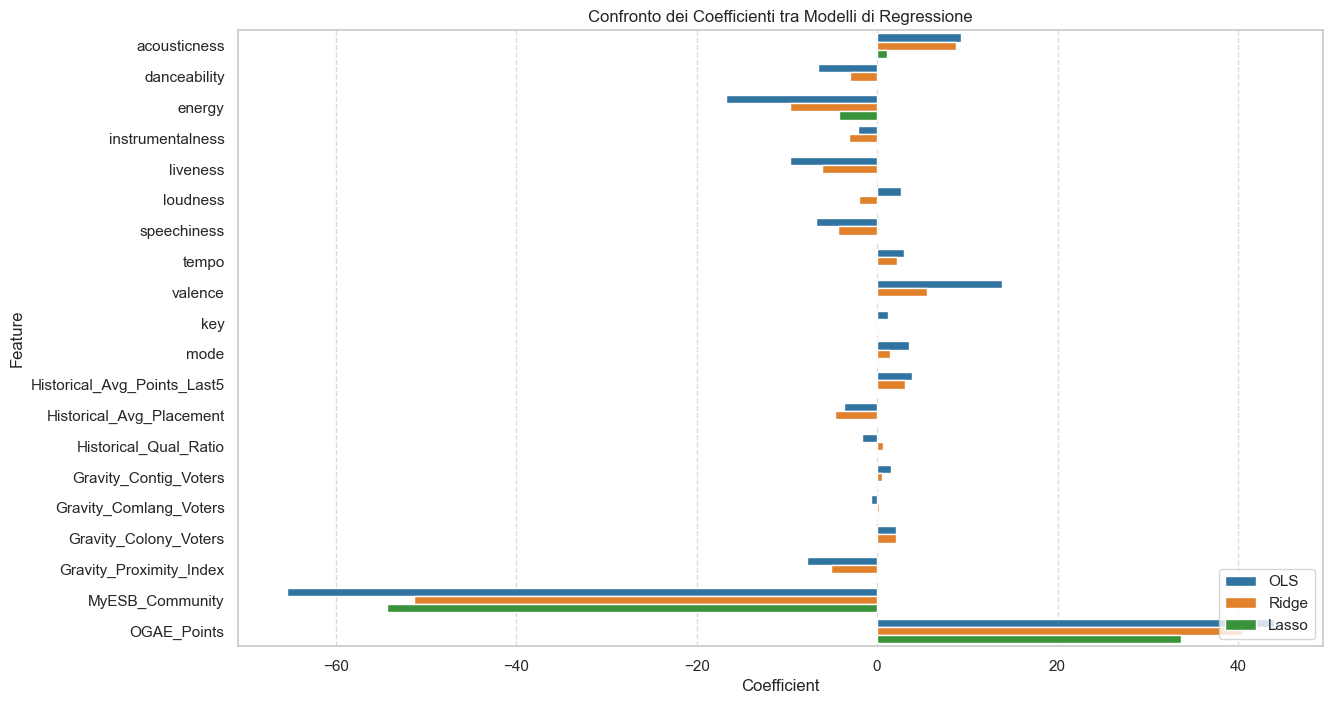

In [35]:
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': features,
    'OLS': ols.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

def highlight_zeros(val):
    if type(val) == float and abs(val) < 1e-5:
        return 'color: lightgray'
    return ''

# Stampiamo quanti coefficienti sono stati azzerati
print("Feature selezionate:")
print(f"OLS: {sum(abs(ols.coef_) > 1e-5)} / {len(features)}")
print(f"Ridge: {sum(abs(ridge.coef_) > 1e-5)} / {len(features)}")
print(f"Lasso: {sum(abs(lasso.coef_) > 1e-5)} / {len(features)}")

display(coef_df.style.applymap(highlight_zeros, subset=['OLS', 'Ridge', 'Lasso']).format({ 
    'OLS': "{:.2f}", 'Ridge': "{:.2f}", 'Lasso': "{:.2f}" 
}))

# Plot dei coefficienti
plt.figure(figsize=(14, 8))
coef_melt = pd.melt(coef_df, id_vars=['Feature'], value_vars=['OLS', 'Ridge', 'Lasso'], 
                    var_name='Model', value_name='Coefficient')
sns.barplot(data=coef_melt, x='Coefficient', y='Feature', hue='Model', palette='tab10')
plt.title('Confronto dei Coefficienti tra Modelli di Regressione')
plt.legend(loc='lower right')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

#### 1. Fan Hype - OGAE e MyESB
L'osservazione più rilevante è il peso delle due variabili legate al *fandom* pre-evento:
* **`OGAE_Points` (Positivo):** Un coefficiente fortemente positivo (~34 in Lasso) indica che i voti dei fan club ufficiali sono un eccellente indicatore del successo reale.
* **`MyESB_Community` (Fortemente Negativo):** Essendo questa variabile un *ranking* , un coefficiente negativo di circa -50 indica che più il ranking si abbassa numericamente (verso il 1° posto), più i punti previsti si alzano vertiginosamente.

#### 2. Feature selection di Lasso
Osservando la colonna `Lasso`, notiamo come l'algoritmo abbia azzerato quasi tutto il dataset, confermando l'alta collinearità. 
Un dato che salta all'occhio è che **tutte le feature storiche e gravitazionali (CEPII) sono state azzerate**. 
Il modello non ci sta dicendo che la geopolitica è inutile, ma che **le variabili dei fan (OGAE/MyESB) assorbono già questa informazione**. Un paese con una forte diaspora o un solido storico di qualificazione (es. Svezia o Ucraina) tende a posizionarsi bene già nei sondaggi pre-evento. Fornire al modello sia i sondaggi che la geografia risulta quindi ridondante, e la penalizzazione L1 scarta le variabili collineari. Ridge, invece, sceglie di mantenerle tutte, comprimendone semplicemente i valori.

#### 3. Audio features
Tra le 11 feature audio estratte da Spotify, solo due riescono a sopravvivere alla feature selection di Lasso:
* **`acousticness`:** Mantiene un leggero coefficiente positivo.
* **`energy`:** Mostra un coefficiente negativo. 
Questo suggerisce che, una volta isolato l'entusiasmo dei fan, il modello premia leggermente brani meno iper-prodotti o caotici, forse indicando un apprezzamento delle giurie verso performance più intime o vocalmente esposte.

## 6. Task B — Classificazione Binaria della Qualificazione in Finale

Spostiamo il focus dalla previsione del *punteggio* alla previsione del *passaggio del turno*: dato un brano in semifinale, qual è la probabilità che si qualifichi alla finale?

Il setup esclude i **Big-6** (Big-5 + paese ospitante) che si qualificano d'ufficio. Confrontiamo quattro famiglie di classificatori:
- **Logistic Regression** (discriminativo): modella direttamente $P(y \mid x)$ con confine di decisione lineare;
- **LDA** (generativo, varianze comuni): assume che le classi siano gaussiane con stessa $\Sigma$;
- **QDA** (generativo, varianze separate): rilassa l'assunzione e ammette confini quadratici;
- **Naive Bayes** (generativo, indipendenza): assume tutte le feature condizionalmente indipendenti.

Le metriche di valutazione utilizzate per confrontare tra loro i classificatori sono: **Accuracy**, **F1**, **ROC-AUC** e **Log-loss**.

### 6.1 Addestramento e confronto dei quattro classificatori

Eseguiamo addestramento, predizione e valutazione di tutti e quattro i modelli su un'unica griglia, restituendo una tabella stilizzata per ispezione comparativa.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 1. Prepariamo il dataset per la qualificazione escludendo i Big-6 (che hanno Big6_Ind == 1)
train_sf = df_train[df_train['Big6_Ind'] == 0].copy()
test_sf = df_test[df_test['Big6_Ind'] == 0].copy()

X_train_B = train_sf[features]
y_train_B = train_sf['Grand_Final_Ind']

X_test_B = test_sf[features]
y_test_B = test_sf['Grand_Final_Ind']

# Standardizziamo
scaler_clf = StandardScaler()
X_train_B_scaled = scaler_clf.fit_transform(X_train_B)
X_test_B_scaled = scaler_clf.transform(X_test_B)

# Inizializzazione dei modelli
models_B = {
    'Logistic Regression': LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Naive Bayes': GaussianNB()
}

# Addestramento e Valutazione
results_B = []

for name, model in models_B.items():
    model.fit(X_train_B_scaled, y_train_B)
    
    # Predizioni classiche e probabilistiche
    y_pred = model.predict(X_test_B_scaled)
    y_prob = model.predict_proba(X_test_B_scaled)[:, 1]
    
    # Metriche
    acc = accuracy_score(y_test_B, y_pred)
    f1 = f1_score(y_test_B, y_pred)
    auc = roc_auc_score(y_test_B, y_prob)
    ll = log_loss(y_test_B, y_prob)
    
    results_B.append({'Modello': name, 'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': auc, 'Log-Loss': ll})

df_results_B = pd.DataFrame(results_B).set_index('Modello')
display(df_results_B.style.highlight_max(subset=['Accuracy', 'F1-Score', 'ROC-AUC'], color='lightgreen')\
                          .highlight_min(subset=['Log-Loss'], color='lightgreen'))

,Accuracy,F1-Score,ROC-AUC,Log-Loss
Modello,,,,
Logistic Regression,0.806452,0.850000,0.877273,0.440452
LDA,0.870968,0.900000,0.868182,0.460894
QDA,0.741935,0.764706,0.850000,0.985097
Naive Bayes,0.709677,0.727273,0.845455,0.839021


**Confronto fra modelli lineari - Logistic Regression e LDA.** I due modelli lineari si dividono il primato sulle quattro metriche: LDA raggiunge la migliore Accuracy (0.871) e il miglior F1-Score (0.900), mentre Logistic Regression ottiene la migliore ROC-AUC (0.877) e il più basso Log-Loss (0.440). La divergenza fra le metriche "hard" (basate su una soglia decisionale fissa al 50%) e quelle "soft" (basate sulla distribuzione delle probabilità predette) suggerisce che i due modelli operano in modo qualitativamente diverso: LDA produce decisioni binarie più accurate, mentre Logistic Regression genera stime probabilistiche meglio calibrate.

**Confronto fra QDA e Naive Bayes.** QDA e Naive Bayes ottengono performance sensibilmente inferiori. Il QDA registra Accuracy 0.742 e un Log-Loss elevato (0.985), pur mantenendo una ROC-AUC accettabile (0.850); il rilassamento dell'assunzione di omoschedasticità introduce un numero maggiore di parametri da stimare ($K \cdot p(p+1)/2$ contro $p(p+1)/2$ dell'LDA), aumentando il rischio di overfitting in un contesto con campionatura limitata. Naive Bayes ottiene i risultati peggiori sulle metriche hard (Accuracy 0.710, F1 0.727), risultato atteso data l'assunzione di indipendenza condizionata fra feature, palesemente violata dalla correlazione documentata fra OGAE_Points e MyESB_Community e fra le audio features.

**Considerazioni sulla scelta del modello.** La selezione del modello migliore dipende dall'obiettivo applicativo: se l'output rilevante è la decisione binaria di qualificazione, l'LDA è preferibile per la maggiore Accuracy e il miglior bilanciamento fra precision e recall; se invece interessa una stima probabilistica calibrata - ad esempio per costruire una classifica ordinale dei paesi in base alla probabilità di qualificazione - Logistic Regression risulta più affidabile. Per le finalità predittive della pipeline adottata, in cui le probabilità verranno usate per ordinare i paesi non-Big6 e selezionare i 20 qualificati, l'adozione di Logistic Regression appare metodologicamente coerente.

## 7. Task C — Classificazione Multi-classe della Fascia di Piazzamento

Ultima estensione: discretizziamo la classifica finale in **quattro fasce ordinali**:
- `1_Top3`: vincitore + podio (place ≤ 3)
- `2_Top10`: alto (place 4–10)
- `3_Top20`: medio (place 11–20)
- `4_Bottom`: bassa classifica (place > 20)

Usiamo la **Regressione Logistica Multinomiale**, naturale estensione del binomiale al caso K-classi via softmax. Lavoriamo solo sui finalisti effettivi.

### 7.1 Addestramento e valutazione del classificatore multinomiale

Discretizziamo `Place_Final` nelle 4 fasce, addestriamo la logistica multinomiale sui finalisti 2016–2024 e valutiamo su quelli del 2025.

Report di Classificazione Multi-classe (Test 2025):

              precision    recall  f1-score   support

      1_Top3       0.17      0.33      0.22         3
     2_Top10       0.50      0.43      0.46         7
     3_Top20       0.12      0.10      0.11        10
    4_Bottom       0.50      0.50      0.50         6

    accuracy                           0.31        26
   macro avg       0.32      0.34      0.32        26
weighted avg       0.32      0.31      0.31        26



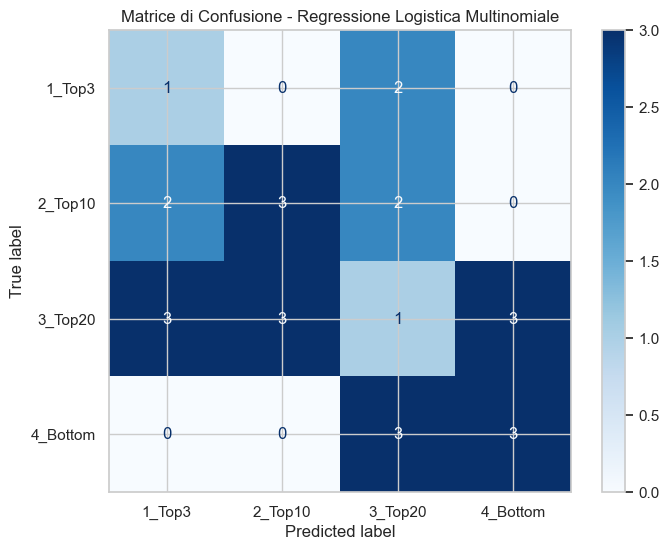

In [37]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1. Definizione delle Fasce di Piazzamento
def discretize_placement(place):
    if pd.isna(place):
        return np.nan
    if place <= 3:
        return '1_Top3'
    elif place <= 10:
        return '2_Top10'
    elif place <= 20:
        return '3_Top20'
    else:
        return '4_Bottom'

# Isolare solo le canzoni arrivate in finale (Place_Final non nullo)
train_final = df_train.dropna(subset=['Place_Final']).copy()
test_final = df_test.dropna(subset=['Place_Final']).copy()

# Applicare la discretizzazione
train_final['Tier'] = train_final['Place_Final'].apply(discretize_placement)
test_final['Tier'] = test_final['Place_Final'].apply(discretize_placement)

X_train_C = train_final[features]
y_train_C = train_final['Tier']

X_test_C = test_final[features]
y_test_C = test_final['Tier']

# Standardizzazione
scaler_multi = StandardScaler()
X_train_C_scaled = scaler_multi.fit_transform(X_train_C)
X_test_C_scaled = scaler_multi.transform(X_test_C)

# Regressione Logistica Multinomiale

multinomial_logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000, random_state=42, class_weight='balanced')
multinomial_logreg.fit(X_train_C_scaled, y_train_C)

# Predizione e Valutazione
y_pred_C = multinomial_logreg.predict(X_test_C_scaled)

print("Report di Classificazione Multi-classe (Test 2025):\n")
print(classification_report(y_test_C, y_pred_C))

# Plot della matrice di confusione
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_C, y_pred_C, cmap='Blues', ax=ax, 
                                        labels=['1_Top3', '2_Top10', '3_Top20', '4_Bottom'])
plt.title('Matrice di Confusione - Regressione Logistica Multinomiale')
plt.show()

I risultati ottenuti dalla Regressione Logistica Multinomiale evidenziano le intrinseche difficoltà nel prevedere i piazzamenti dell'Eurovision utilizzando confini di decisione strettamente lineari. 

L'**accuratezza globale si attesta al 31%**: un valore modesto se consideriamo che, con 4 classi bilanciate, una scelta puramente casuale produrrebbe un'accuratezza teorica del 25%. Questo indica che il modello fatica a discriminare in modo netto le diverse fasce di classifica.

Osservando il **Report di Classificazione** e la **Matrice di Confusione**, emergono le seguenti osservazioni:

*   **Le fasce estreme e la Top 10:** Il modello si comporta relativamente meglio per la classe `4_Bottom` (F1-score: **0.50**) e per la classe `2_Top10` (F1-score: **0.46**). Riesce a individuare correttamente 3 canzoni su 6 per gli ultimi posti e 3 canzoni su 7 per la Top 10.
*   **La confusione del "ventre della classifica" (`3_Top20`):** Questa è la classe che mette più in crisi il modello (Recall del **10%** e F1-score di **0.11**). Su 10 canzoni che si sono classificate tra l'undicesimo e il ventesimo posto, il modello ne individua correttamente solo 1. Le restanti vengono disperse quasi uniformemente tra Top 3, Top 10 e Bottom.
*   **Falsi Positivi per la Top 3:** Il modello tende a sovrastimare le potenzialità di alcune canzoni. Prevede ben 6 brani nella `1_Top3`, ma solo 1 di questi appartiene realmente a questa categoria.

**Possibili cause e interpretazioni:**
1.  **Limiti della linearità:** La regressione logistica traccia confini lineari tra le classi. Il successo all'Eurovision dipende spesso da combinazioni non lineari di fattori.
2.  **Sovrapposizione delle feature (Collinearità):** Come già anticipato, le metriche audio di Spotify sono spesso fortemente correlate, il che può confondere i pesi del modello.
3.  **Supporto limitato:** Il test set conta solo 26 osservazioni (i finalisti), rendendo le metriche di valutazione molto sensibili ai singoli errori di predizione.

## 8. Fase Finale - Predizione Eurovision 2026

Combiniamo i tre modelli selezionati per generare una **classifica predittiva completa** per le 35 nazioni partecipanti all'Eurovision 2026.

### 8.1 Generazione della leaderboard predetta 2026

Selezioniamo automaticamente il modello migliore per ciascun task e applichiamo le predizioni al `df_pred` (Year = 2026). Costruiamo poi un DataFrame riassuntivo che combina, per ogni paese:
- la stima dei punti finali (Task A);
- la probabilità di qualificazione in finale (Task B);
- la fascia di piazzamento più probabile (Task C);
- la classifica complessiva ordinata per punti predetti.

In [ ]:
# Selezione automatica dei migliori modelli dai Task precedenti
best_model_A = models[best_model_name]

best_model_B_name = df_results_B['ROC-AUC'].idxmax()
best_model_B = models_B[best_model_B_name]

best_model_C = multinomial_logreg

print(f"Modello selezionato per Task A (Punti): {best_model_name}")
print(f"Modello selezionato per Task B (Qualificazione): {best_model_B_name}")
print(f"Modello selezionato per Task C (Fascia): Regressione Logistica Multinomiale\n")

# Isoliamo le feature per il 2026
X_pred = df_pred[features]

# Prepariamo il DataFrame finale
results_2026 = df_pred[['Country', 'Artist', 'Song', 'Big6_Ind','iso3']].copy()

# --------------------------------------------------------
# Task A: Predizione Punteggio Totale
X_pred_scaled_A = scaler_reg.transform(X_pred)
results_2026['Predicted_Points'] = best_model_A.predict(X_pred_scaled_A).round(1)


# --------------------------------------------------------
# Task B: Predizione Qualificazione (Solo per Non-Big6)
X_pred_scaled_B = scaler_clf.transform(X_pred)
prob_qual = best_model_B.predict_proba(X_pred_scaled_B)[:, 1]
results_2026['Qualification_Prob'] = prob_qual

# Impostiamo a 1.0 le probabilità dei Big-6 (Qualificazione automatica)
results_2026.loc[results_2026['Big6_Ind'] == 1, 'Qualification_Prob'] = 1.0

# Selezioniamo i migliori 20 tra i Non-Big 6
NUM_POSTI_NON_BIG6 = 20

# Isoliamo i non-Big6 usando != 1 (più sicuro) e ordiniamo
non_big6 = results_2026[results_2026['Big6_Ind'] != 1].sort_values(by='Qualification_Prob', ascending=False)

# Identifichiamo i 20 paesi con la probabilità più alta usando 'Country' 
qualificati_dal_modello = non_big6.head(NUM_POSTI_NON_BIG6)['Country'].values

# Assegniamo il flag di qualificazione
results_2026['Predicted_Finalist'] = ((results_2026['Big6_Ind'] == 1) | (results_2026['Country'].isin(qualificati_dal_modello))).astype(int)

results_2026['Qualification_Prob'] = results_2026['Qualification_Prob'].apply(lambda x: f"{x:.1%}")

# --------------------------------------------------------
# Task C: Predizione Fascia di Piazzamento
X_pred_scaled_C = scaler_multi.transform(X_pred)
results_2026['Predicted_Tier'] = best_model_C.predict(X_pred_scaled_C)

# Pulizia visiva per la Fascia
results_2026['Predicted_Tier'] = results_2026['Predicted_Tier'].str.replace(r'\d+_', '', regex=True)


# Ordinamento simulato della Leaderboard in base ai punti previsti
results_2026 = results_2026.sort_values(by='Predicted_Points', ascending=False).reset_index(drop=True)
results_2026.index += 1  # Ranking da 1 a 35
results_2026.index.name = 'Simulated_Rank'

# Visualizzazione Top 10 per controllo rapido
display(results_2026.head(35).style.background_gradient(subset=['Predicted_Points'], cmap='YlGnBu'))

Modello selezionato per Task A (Punti): Ridge
Modello selezionato per Task B (Qualificazione): Logistic Regression
Modello selezionato per Task C (Fascia): Regressione Logistica Multinomiale



,Country,Artist,Song,Big6_Ind,iso3,Predicted_Points,Qualification_Prob,Predicted_Finalist,Predicted_Tier
Simulated_Rank,,,,,,,,,
1,Sweden,Felicia,My System,nan,SWE,290.200000,99.2%,1,Top3
2,France,Monroe,Regarde!,1.000000,FRA,278.900000,100.0%,1,Top10
3,Greece,Aklas,Ferto,nan,GRC,232.800000,98.7%,1,Top3
4,Finland,Linda Lampenius and Pete Parkkonen,Liekinheitin,nan,FIN,229.500000,99.4%,1,Top3
5,Cyprus,Antigoni,Jalla,nan,CYP,223.400000,98.1%,1,Top3
6,Italy,Sal Dav Vinci,Per sempre si,1.000000,ITA,214.000000,100.0%,1,Top10
7,Bulgaria,Dara,Bangaranga,nan,BGR,212.700000,98.7%,1,Top10
8,Denmark,Soren Torpegaard Lund,For vi gar hjem,nan,DNK,208.500000,98.6%,1,Top3
9,Australia,Delta Goodrem,Eclipse,nan,AUS,207.200000,97.1%,1,Top3


# 9. Conclusioni

Il presente progetto ha sviluppato una pipeline per la previsione dei risultati dell'Eurovision Song Contest 2026, articolata su tre task complementari - regressione del punteggio finale, classificazione binaria della qualificazione in finale e classificazione multi-classe della fascia di piazzamento - e fondata esclusivamente su metodi lineari e probabilistici. L'impianto metodologico ha integrato quattro fonti di dati eterogenee (risultati storici 2016–2025, audio features Spotify, voti bilaterali e dataset CEPII), validate attraverso uno schema di split cronologico rigoroso (train 2016–2024, hold-out 2025, predizione 2026) e ottimizzate mediante cross-validation temporale (`TimeSeriesSplit`) per riprodurre fedelmente le condizioni di generalizzazione fuori campione.

## 9.1 Principali evidenze empiriche

L'analisi condotta consente di formulare quattro conclusioni sostanziali, ciascuna supportata da risultati quantitativi.

**Sul piano della regressione (Task A)**, la regolarizzazione si è dimostrata essenziale per la gestione della multicollinearità documentata nell'EDA. Il modello Ridge ha ottenuto le migliori performance sul hold-out 2025 (MAE = 77.95 punti, RMSE = 94.54, R² = 0.278), superando sistematicamente sia l'OLS non regolarizzato (MAE = 85.61, R² = 0.173) sia il Lasso (MAE = 78.67, R² = 0.228). Il valore di R² attorno al 28%, apparentemente modesto in altri domini applicativi, risulta consistente con la natura intrinsecamente stocastica del fenomeno Eurovision, in cui una quota rilevante della varianza è attribuibile a fattori non strutturati ex ante (resa vocale, staging, dinamiche di televoto).

**Sul piano della selezione delle feature**, l'analisi dei coefficienti ha rivelato la dominanza inequivocabile delle metriche di engagement comunitario: `OGAE_Points` (coefficiente Lasso = +33.65) e `MyESB_Community` (coefficiente Lasso = −54.35) sono le uniche variabili, insieme a `acousticness` ed `energy`, a sopravvivere alla feature selection L1 con α = 15.20. Questo risultato suggerisce che gli indicatori di popolarità pre-show assorbono, in forma compressa, l'informazione gravitazionale e storica che le altre feature tentavano di catturare separatamente: un paese con forte pedigree storico e ampio bacino di diaspora tende infatti a posizionarsi alto nei sondaggi di fan club già prima della competizione. La penalizzazione L1 ha dunque rivelato non l'irrilevanza delle Gravity Features e delle feature storiche in sé, ma la loro ridondanza informativa rispetto al segnale aggregato dei sondaggi pre-evento.

**Sul piano della classificazione binaria (Task B)**, il confronto sistematico tra modelli discriminativi e generativi ha prodotto un risultato metodologicamente significativo: i due classificatori lineari (Logistic Regression e LDA) hanno dominato in modo complementare le quattro metriche di valutazione. L'LDA ha conseguito la migliore Accuracy (0.871) e il miglior F1-Score (0.900), indicando una superiore capacità decisionale alla soglia 0.5; la Logistic Regression ha invece ottenuto la migliore ROC-AUC (0.877) e il più basso Log-Loss (0.440), evidenziando una calibrazione probabilistica più affidabile. Il QDA e il Naive Bayes hanno mostrato performance sensibilmente inferiori, riconducibili rispettivamente all'eccessivo numero di parametri da stimare in regime di campionatura limitata e alla violazione manifesta dell'assunzione di indipendenza condizionata. La sostanziale convergenza dei modelli lineari sulle prime due posizioni costituisce un'evidenza empirica forte a favore della **natura lineare del confine di separazione** tra qualificati ed eliminati.

**Sul piano della classificazione multi-classe (Task C)**, la Regressione Logistica Multinomiale ha raggiunto un'accuratezza globale del 31% sulle quattro fasce ordinali, superiore al baseline casuale (25%) ma manifestamente insufficiente per una discriminazione operativa affidabile. La criticità principale risiede nella classe `3_Top20` (recall = 10%), che rappresenta il "ventre della classifica" privo di tratti distintivi netti, e nella tendenza alla sovrastima della fascia `1_Top3` (precision = 17%). Questo risultato circoscrive il limite naturale dell'approccio lineare nel discriminare configurazioni di posizionamento in cui le frontiere fra classi sono intrinsecamente sfumate e plausibilmente non lineari.

## 9.2 Limiti del lavoro

Si riconoscono onestamente i seguenti limiti, che circoscrivono la portata interpretativa dei risultati. Il **supporto campionario del hold-out 2025** è limitato (37 osservazioni complessive, di cui 26 finalisti), il che rende le metriche di valutazione sensibili ai singoli errori di predizione e richiede cautela nella generalizzazione delle conclusioni. L'**imputazione con mediana globale** delle audio features mancanti ha introdotto spike artificiali nelle distribuzioni di `energy`, `danceability`, `loudness` e `tempo`, riducendo la varianza informativa effettiva di questo blocco di predittori - un compromesso accettabile in fase di pre-processing, ma da migliorare con strategie di imputazione condizionate al genere musicale o all'artista. La **restrizione metodologica ai modelli lineari** esclude per costruzione famiglie di algoritmi (come per esempio alberi decisionali e reti neurali) che potrebbero catturare interazioni non lineari potenzialmente rilevanti, in particolare nel Task C dove la struttura ordinale delle fasce di piazzamento suggerisce confini decisionali curvi. Infine, l'**imprevedibilità intrinseca dell'evento** - staging, performance vocale serale, ordine di esibizione effettivo, dinamiche geopolitiche dell'ultimo minuto - pone un limite informativo superiore alla qualità predittiva di qualunque modello costruito su feature ex ante.

## 9.3 Sviluppi futuri

Diverse direzioni di ricerca emergono naturalmente dai risultati ottenuti. Sul piano modellistico, sarebbe metodologicamente coerente affiancare ai modelli lineari un benchmark non lineare per quantificare il *gap* informativo attribuibile alle interazioni di ordine superiore, in particolare nel Task C. Sul piano delle feature, l'introduzione di **embedding testuali dei testi delle canzoni** (via modelli NLP pre-addestrati) e di **feature di sentiment** estratte dai social media nelle settimane precedenti il contest potrebbe arricchire significativamente il blocco di fan-hype, attualmente concentrato sui soli sondaggi OGAE/MyESB. Sul piano della validazione, l'estensione dello storico a finestre temporali più ampie (pre-2016) consentirebbe una stima più robusta dei coefficienti gravitazionali e una valutazione cross-validata su più hold-out cronologici. Sul piano applicativo, infine, l'integrazione della pipeline con aggiornamenti incrementali settimanali dei sondaggi pre-evento permetterebbe di produrre predizioni dinamiche calibrate fino alla vigilia del contest, con potenziali ricadute per scommettitori, broadcaster e analisti del fenomeno.

## 9.4 Considerazione conclusiva

In ultima analisi, il progetto ha dimostrato che una pipeline di Machine Learning interpretabile, costruita esclusivamente su metodi lineari e probabilistici classici e rigorosamente validata in regime temporale, è in grado di produrre stime predittive coerenti e diagnosticamente leggibili per un fenomeno complesso come l'Eurovision Song Contest. Il risultato più significativo non risiede tanto nei singoli valori delle metriche, quanto nell'evidenza che - al netto del rumore stocastico del contest - la combinazione di **segnale di fan-engagement**, **regolarizzazione L2** e **validazione temporale** è sufficiente a catturare in modo strutturato la dinamica predominante del fenomeno. La linearità del confine di separazione fra qualificati ed eliminati, confermata dalla convergenza di Logistic Regression e LDA, suggerisce inoltre che la complessità apparente del concorso si lascia decomporre in componenti additive interpretabili, validando l'impianto epistemologico dei modelli lineari come strumento di analisi quantitativa anche in domini dominati da dinamiche socio-culturali eterogenee.